In [1]:
import glob
import corner
import sep

import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
from matplotlib.ticker import LogFormatterMathtext
from matplotlib import gridspec
import matplotlib.lines as mlines

import pandas as pd
import numpy as np
import seaborn as sns

from astropy.table import Table, vstack
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.convolution import convolve_fft, Gaussian2DKernel
from astropy.nddata import block_reduce
from astropy.table.notebook_backends import ipydatagrid
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

from photutils.detection import find_peaks

from bt_functions import grab_image, add_noise, plot_object, reduce, get_scale_pkpc, get_scale_as

In [2]:
# ---------------------------
# -------- LOAD DATA --------
# ---------------------------

# redshift 7 is the default
# BlueTides data covers redshifts 7-12
redshift = 7

bluetides_path = '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_*/hlsp_bluetides_jwst_nircam_z{redshift}*_f*w_v1_sim-*.fits'
img_path = '/Volumes/SeagateBack/bluetides/plots'
code_path = '/Volumes/SeagateBack/bluetides/code'

filenames = glob.glob(bluetides_path.format(redshift=redshift))       # finds all files in path with given format 
print("Number of files:",len(filenames))                        # there are 56 files in total for z=7

# catalog = Table.read('/Volumes/SeagateBack/bluetides/code/og_catalog.ecsv')
catalog = Table.read('/Volumes/SeagateBack/bluetides/code/hlsp_bluetides_multi_multi_all_multi_v2_sim.csv')
if 'id' in catalog.colnames:
    catalog.replace_column('id', 1 + np.arange(len(catalog)))
else:
    catalog.add_column(1 + np.arange(len(catalog)), name='id', index=0)
catalog.write('og_catalog.ecsv', overwrite=True)

catalog[:10]

Number of files: 56


id,col0,redshift,fileNumber,extensionNumber,stellarMass,BHmass,BHluminosity,haloMass,lum_FUV,flux_jwst.nircam.f090w,radius_jwst.nircam.f090w,flux_jwst.nircam.f115w,radius_jwst.nircam.f115w,flux_jwst.nircam.f150w,radius_jwst.nircam.f150w,flux_jwst.nircam.f200w,radius_jwst.nircam.f200w,flux_jwst.nircam.f277w,radius_jwst.nircam.f277w,flux_jwst.nircam.f356w,radius_jwst.nircam.f356w,flux_jwst.nircam.f410m,radius_jwst.nircam.f410m,flux_jwst.nircam.f444w,radius_jwst.nircam.f444w,flux_jwst.miri.f560w,radius_jwst.miri.f560w,flux_jwst.miri.f770w,radius_jwst.miri.f770w,flux_hst.wfc3.f105w,radius_hst.wfc3.f105w,flux_hst.wfc3.f125w,radius_hst.wfc3.f125w,flux_hst.wfc3.f140w,radius_hst.wfc3.f140w,flux_hst.wfc3.f160w,radius_hst.wfc3.f160w,flux_euclid.nisp.y,radius_euclid.nisp.y,flux_euclid.nisp.j,radius_euclid.nisp.j,flux_euclid.nisp.h,radius_euclid.nisp.h,flux_roman.wfi.f087,radius_roman.wfi.f087,flux_roman.wfi.f106,radius_roman.wfi.f106,flux_roman.wfi.f129,radius_roman.wfi.f129,flux_roman.wfi.f146,radius_roman.wfi.f146,flux_roman.wfi.f158,radius_roman.wfi.f158,flux_roman.wfi.f184,radius_roman.wfi.f184,flux_subaru.hsc.z,radius_subaru.hsc.z,flux_subaru.hsc.y,radius_subaru.hsc.y,flux_vista.vircam.z,radius_vista.vircam.z,flux_vista.vircam.y,radius_vista.vircam.y,flux_vista.vircam.j,radius_vista.vircam.j,flux_vista.vircam.h,radius_vista.vircam.h,flux_vista.vircam.ks,radius_vista.vircam.ks,flux_spitzer.irac.ch1,flux_spitzer.irac.ch2
int64,int64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,0,7.0,1,1,62058380000.0,374432960.0,9.854875355041004e+46,1292328500000.0,1.2920170160111174e+29,23.11590576171875,1.2503641843795776,169.21633911132812,1.1419026851654053,186.37940979003906,1.058977723121643,195.3888702392578,0.99473637342453,261.0684814453125,0.893967866897583,470.4862060546875,0.8837507963180542,635.4224243164062,0.8629537224769592,543.959228515625,0.8785976767539978,623.2904052734375,1.012123703956604,682.6275024414062,1.0523561239242554,125.1771011352539,1.2744066715240479,175.79356384277344,1.2591437101364136,183.14561462402344,1.2591437101364136,188.14297485351562,1.2591437101364136,183.15052795410156,1.7575469017028809,221.62730407714844,1.7575469017028809,227.99705505371094,1.6979515552520752,9.006768226623535,1.2672045230865479,129.13966369628906,1.2562328577041626,178.63833618164062,1.233996868133545,171.67251586914062,1.233996868133545,189.06185913085938,1.2227272987365723,192.5867462158203,1.233996868133545,13.57265567779541,2.1514832973480225,81.3726806640625,2.182002305984497,48.2589225769043,2.300032377243042,212.34750366210938,2.300032377243042,218.61846923828125,2.2417943477630615,241.94602966308594,2.2417943477630615,243.62803649902344,2.2417943477630615,503.7591247558594,553.727783203125
2,1,7.0,1,2,129293664000.0,365300220.0,9.614507498709602e+46,8704022300000.0,6.276021859962179e+29,104.62671661376953,1.5874279737472534,813.4927978515625,1.5317360162734985,980.5615234375,1.4836066961288452,1121.8316650390625,1.4498753547668457,1516.3748779296875,1.3743971586227417,2676.136962890625,1.3842731714248657,3508.948974609375,1.4421098232269287,3085.17578125,1.3842731714248657,3377.263916015625,1.4975289106369019,3822.9365234375,1.4882562160491943,595.3988037109375,1.5608230829238892,861.0501708984375,1.5608230829238892,931.8605346679688,1.5608230829238892,1000.8505859375,1.5608230829238892,1080.4014892578125,2.313918113708496,1379.1951904296875,2.313918113708496,1548.9696044921875,2.357996702194214,37.4470329284668,1.5872795581

In [3]:
# ------------------------------
# --- FORMATTING FIGURE TEXT ---
# ------------------------------
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "cm",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "mathtext.rm": "serif",
    "mathtext.it": "serif:italic",
    "mathtext.bf": "serif:bold",
    "axes.labelsize": 18,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "axes.titlesize": 18
})

In [4]:
catalog[:10]

id,col0,redshift,fileNumber,extensionNumber,stellarMass,BHmass,BHluminosity,haloMass,lum_FUV,flux_jwst.nircam.f090w,radius_jwst.nircam.f090w,flux_jwst.nircam.f115w,radius_jwst.nircam.f115w,flux_jwst.nircam.f150w,radius_jwst.nircam.f150w,flux_jwst.nircam.f200w,radius_jwst.nircam.f200w,flux_jwst.nircam.f277w,radius_jwst.nircam.f277w,flux_jwst.nircam.f356w,radius_jwst.nircam.f356w,flux_jwst.nircam.f410m,radius_jwst.nircam.f410m,flux_jwst.nircam.f444w,radius_jwst.nircam.f444w,flux_jwst.miri.f560w,radius_jwst.miri.f560w,flux_jwst.miri.f770w,radius_jwst.miri.f770w,flux_hst.wfc3.f105w,radius_hst.wfc3.f105w,flux_hst.wfc3.f125w,radius_hst.wfc3.f125w,flux_hst.wfc3.f140w,radius_hst.wfc3.f140w,flux_hst.wfc3.f160w,radius_hst.wfc3.f160w,flux_euclid.nisp.y,radius_euclid.nisp.y,flux_euclid.nisp.j,radius_euclid.nisp.j,flux_euclid.nisp.h,radius_euclid.nisp.h,flux_roman.wfi.f087,radius_roman.wfi.f087,flux_roman.wfi.f106,radius_roman.wfi.f106,flux_roman.wfi.f129,radius_roman.wfi.f129,flux_roman.wfi.f146,radius_roman.wfi.f146,flux_roman.wfi.f158,radius_roman.wfi.f158,flux_roman.wfi.f184,radius_roman.wfi.f184,flux_subaru.hsc.z,radius_subaru.hsc.z,flux_subaru.hsc.y,radius_subaru.hsc.y,flux_vista.vircam.z,radius_vista.vircam.z,flux_vista.vircam.y,radius_vista.vircam.y,flux_vista.vircam.j,radius_vista.vircam.j,flux_vista.vircam.h,radius_vista.vircam.h,flux_vista.vircam.ks,radius_vista.vircam.ks,flux_spitzer.irac.ch1,flux_spitzer.irac.ch2
int64,int64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,0,7.0,1,1,62058380000.0,374432960.0,9.854875355041004e+46,1292328500000.0,1.2920170160111174e+29,23.11590576171875,1.2503641843795776,169.21633911132812,1.1419026851654053,186.37940979003906,1.058977723121643,195.3888702392578,0.99473637342453,261.0684814453125,0.893967866897583,470.4862060546875,0.8837507963180542,635.4224243164062,0.8629537224769592,543.959228515625,0.8785976767539978,623.2904052734375,1.012123703956604,682.6275024414062,1.0523561239242554,125.1771011352539,1.2744066715240479,175.79356384277344,1.2591437101364136,183.14561462402344,1.2591437101364136,188.14297485351562,1.2591437101364136,183.15052795410156,1.7575469017028809,221.62730407714844,1.7575469017028809,227.99705505371094,1.6979515552520752,9.006768226623535,1.2672045230865479,129.13966369628906,1.2562328577041626,178.63833618164062,1.233996868133545,171.67251586914062,1.233996868133545,189.06185913085938,1.2227272987365723,192.5867462158203,1.233996868133545,13.57265567779541,2.1514832973480225,81.3726806640625,2.182002305984497,48.2589225769043,2.300032377243042,212.34750366210938,2.300032377243042,218.61846923828125,2.2417943477630615,241.94602966308594,2.2417943477630615,243.62803649902344,2.2417943477630615,503.7591247558594,553.727783203125
2,1,7.0,1,2,129293664000.0,365300220.0,9.614507498709602e+46,8704022300000.0,6.276021859962179e+29,104.62671661376953,1.5874279737472534,813.4927978515625,1.5317360162734985,980.5615234375,1.4836066961288452,1121.8316650390625,1.4498753547668457,1516.3748779296875,1.3743971586227417,2676.136962890625,1.3842731714248657,3508.948974609375,1.4421098232269287,3085.17578125,1.3842731714248657,3377.263916015625,1.4975289106369019,3822.9365234375,1.4882562160491943,595.3988037109375,1.5608230829238892,861.0501708984375,1.5608230829238892,931.8605346679688,1.5608230829238892,1000.8505859375,1.5608230829238892,1080.4014892578125,2.313918113708496,1379.1951904296875,2.313918113708496,1548.9696044921875,2.357996702194214,37.4470329284668,1.5872795581

In [5]:
# ------------------------
# --- LOAD DATA TABLES ---
# ------------------------
roc_Table = Table.read(f'{code_path}/sep_table.ecsv')
f150w_Table = Table.read(f'{code_path}/sep_table_f150w.ecsv')
f444w_Table = Table.read(f'{code_path}/sep_table_f444w.ecsv')
conv_34_Table = Table.read(f'{code_path}/sep_table_f150w_extended.ecsv')

# REPLACE LUM FUV COLUMN IN ALL TABLES USING NEW CATALOG
lum_map = {row['id']: row['lum_FUV'] for row in catalog}

def replace_luminosity(table, lum_map):
    table_ids = table['id'].astype(int)
    table['lumFUV'] = [lum_map.get(i, np.nan) for i in table_ids]
    return table

roc_Table     = replace_luminosity(roc_Table, lum_map)
f150w_Table   = replace_luminosity(f150w_Table, lum_map)
f444w_Table   = replace_luminosity(f444w_Table, lum_map)
conv_34_Table = replace_luminosity(conv_34_Table, lum_map)

missing = set(f150w_Table['id']) - set(catalog['id'])
print("Missing IDs:", missing)

f444w_Table

Missing IDs: set()


id,haloMass,bhMass,stellarMass,lumFUV,convolution,distances,flux_ratio,area_1,area_2,has_psf
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.0,0.0,0.0,0.0,0.0,False
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.5,0.0,0.0,0.0,0.0,False
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,1.0,0.0,0.0,0.0,0.0,False
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,2.0,0.0,0.0,0.0,0.0,False
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,5.0,0.0,0.0,0.0,0.0,False
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.0,0.0,0.0,0.0,0.0,True
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.5,0.0,0.0,0.0,0.0,True
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,1.0,0.0,0.0,0.0,0.0,True
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,2.0,0.0,0.0,0.0,0.0,True


In [6]:
# -------------------------------------
# ------ GET SCALES FROM HEADERS ------
# -------------------------------------

scale_pkpc = get_scale_pkpc(
    1, 
    filter='f150w', 
    redshift=7, 
    catalog=catalog, 
    filenames=filenames
    )

scale_as = get_scale_as(
    1, 
    filter='f150w', 
    redshift=7, 
    catalog=catalog, 
    filenames=filenames
    )

print("SCALE PKPC:",scale_pkpc)
print("SCALE AS:", scale_as)

scale = []
for i in range(1000):
    scale_as = get_scale_as(i+1, filter='f150w', redshift=7, catalog=catalog, filenames=filenames)
    scale += [scale_as]

print(np.unique(scale))

# SCALE OF THE DETECTION KERNELS:
convolutions = [0,0.5,1,2,5]
conv_as = np.unique(scale)*convolutions
print("kernel sizes in arcsec:\n", conv_as)

SCALE PKPC: 0.08311448
SCALE AS: 0.0155
[0.0155]
kernel sizes in arcsec:
 [0.      0.00775 0.0155  0.031   0.0775 ]


In [7]:
# ------------------------------------
# -------- DISTANCES IN PKPC --------
# ------------------------------------
f150w_Table_joined = vstack([f150w_Table, conv_34_Table])


unique_ids = np.unique(f150w_Table['id'])
scale_pkpc = {}
scale_as = {}

for id in unique_ids:
    try:
        scale_pkpc[id] = get_scale_pkpc(id, filter='f150w', redshift=7, catalog=catalog, filenames=filenames)
        scale_as[id] = get_scale_as(id, filter='f150w', redshift=7, catalog=catalog, filenames=filenames)
    except:
        print(f"Could not load scale for id={id}")


# Map ID → scale, then broadcast
f150w_Table_joined['distance_pkpc'] = [
    scale_pkpc[row['id']] * row['distances'] 
    for row in f150w_Table_joined
]
f150w_Table_joined['distance_as'] = [
    scale_as[row['id']] * row['distances'] 
    for row in f150w_Table_joined
]
f150w_Table_joined


id,haloMass,bhMass,stellarMass,lumFUV,convolution,distances,flux_ratio,area_1,area_2,has_psf,distance_pkpc,distance_as
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,float64,float64
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.0,5.8341918239615005,0.5927456669607006,50.0,60.0,False,0.4849058196688117,0.09042997327140326
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.5,11.315334820295579,0.2710036965865495,48.0,115.0,False,0.9404681696147605,0.17538768971458146
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,1.0,4.458249248190907,0.47129277006608244,85.0,176.0,False,0.37054506797377823,0.06910286334695906
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,2.0,0.0,0.0,0.0,0.0,False,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,5.0,0.0,0.0,0.0,0.0,False,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.0,0.0,0.0,0.0,0.0,True,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.5,0.0,0.0,0.0,0.0,True,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,1.0,0.0,0.0,0.0,0.0,True,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,2.0,0.0,0.0,0.0,0.0,True,0.0,0.0


In [8]:
# ------------------------------------
# -------- DISTANCES IN PKPC --------
# ------------------------------------
unique_ids = np.unique(f150w_Table['id'])
scale_pkpc = {}
scale_as = {}

for id in unique_ids:
    try:
        scale_pkpc[id] = get_scale_pkpc(id, filter='f150w', redshift=7, catalog=catalog, filenames=filenames)
        scale_as[id] = get_scale_as(id, filter='f150w', redshift=7, catalog=catalog, filenames=filenames)
    except:
        print(f"Could not load scale for id={id}")


# Map ID → scale, then broadcast
f150w_Table['distance_pkpc'] = [
    scale_pkpc[row['id']] * row['distances'] 
    for row in f150w_Table
]
f150w_Table['distance_as'] = [
    scale_as[row['id']] * row['distances'] 
    for row in f150w_Table
]
f150w_Table


# Map ID → scale, then broadcast
f444w_Table['distance_pkpc'] = [
    scale_pkpc[row['id']] * row['distances'] 
    for row in f444w_Table
]
f444w_Table['distance_as'] = [
    scale_as[row['id']] * row['distances'] 
    for row in f444w_Table
]
f444w_Table

id,haloMass,bhMass,stellarMass,lumFUV,convolution,distances,flux_ratio,area_1,area_2,has_psf,distance_pkpc,distance_as
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,float64,float64
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.0,0.0,0.0,0.0,0.0,False,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.5,0.0,0.0,0.0,0.0,False,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,1.0,0.0,0.0,0.0,0.0,False,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,2.0,0.0,0.0,0.0,0.0,False,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,5.0,0.0,0.0,0.0,0.0,False,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.0,0.0,0.0,0.0,0.0,True,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.5,0.0,0.0,0.0,0.0,True,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,1.0,0.0,0.0,0.0,0.0,True,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,2.0,0.0,0.0,0.0,0.0,True,0.0,0.0


In [9]:
# Create a set of known pair indices to define ground truth
# By-eye pairs
pair_indices = {
    2, 8, 13, 17, 19, 25, 27, 33, 37, 38, 41, 57, 62, 64, 72, 76, 79, 87, 88, 90,
    93, 94, 95, 97, 98, 99, 105, 107, 109, 112, 117, 128, 136, 147, 167, 171, 184,
    191, 199, 201, 204, 209, 217, 228, 233, 285, 311, 326, 330, 332, 344, 357, 364,
    385, 388, 396, 402, 405, 407, 433, 456, 469, 472, 494, 504, 511, 523, 530, 556,
    559, 568, 616, 617, 625, 640, 641, 650, 657, 664, 669, 678, 681, 683, 727, 729,
    745, 749, 760, 773, 794, 800, 802, 814, 821, 830, 845, 850, 852, 870, 879, 903,
    915, 919, 954, 987, 997
}
# Create arrays for pairs and non-pairs under 1000
all_indices = set(range(1000))
non_pairs = sorted(all_indices - pair_indices)
print(len(pair_indices)/1000)
pairs = sorted(pair_indices)

0.106


findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Fo

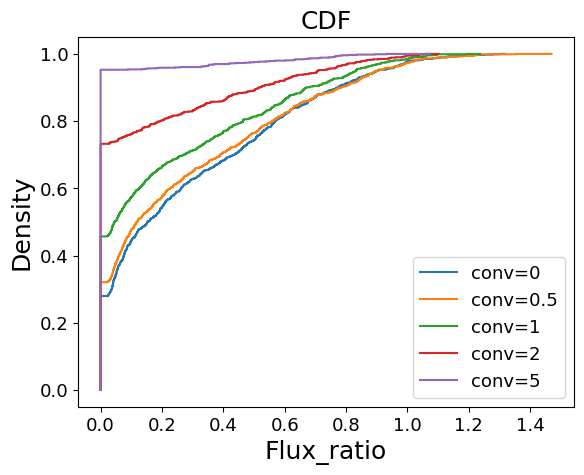

In [10]:
def cumulative(x):
    x = x[~np.isnan(x)]
    N = len(x)
    return np.sort(x), np.array(np.linspace(0,N,N) )/float(N)


# CDF's of the flux ratios for each convolution kernel
det_k = [0,0.5,1,2,5]

for conv in det_k:
    flux = roc_Table[(roc_Table['convolution'] == conv)&(roc_Table['has_psf']==True)]['flux_ratio']
    x,y = cumulative(flux)
    plt.step(x,y,label=f'conv={conv}')

plt.xlabel(f"Flux_ratio")
plt.ylabel(f"Density")
plt.title("CDF")
plt.legend()

In [11]:
# -------------------------------
# --- FUNCTIONS FOR ROC RATES ---
# -------------------------------

def get_tpr(metric, pair_list, fixed_thresholds=None):
    """
    Calculates true positive rate    
    """
    tpr_list = []

    if fixed_thresholds is None:
        thresholds, _ = cumulative(metric)
    else:
        thresholds = fixed_thresholds

    for t in thresholds:
        predicted_pair = (metric > t).astype(np.int8)
        TP = ((predicted_pair == 1) & (pair_list == 1)).sum()
        FN = ((predicted_pair == 0) & (pair_list == 1)).sum()
        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        tpr_list.append(TPR)

    return thresholds, np.array(tpr_list)



def get_fpr(metric,pair_list):
    """
    Calculates false positive rate    
    """
    fpr_list = []
    thresholds, _ = cumulative(metric)

    for t in thresholds:
        predicted_pair = (metric > t).astype(np.int8)
        FP = ((predicted_pair == 1) & (pair_list == 0)).sum()  # False Positives
        TN = ((predicted_pair == 0) & (pair_list == 0)).sum()  # True Negatives
        FPR = FP / (TN + FP) if (TN + FP) > 0 else 0

        fpr_list.append(FPR)
    return thresholds, np.array(fpr_list)


def get_tnr(metric,pair_list):
    """
    Calculates true negative rate    
    """
    tnr_list = []
    thresholds, _ = cumulative(metric)

    for t in thresholds:
        predicted_pair = (metric > t).astype(np.int8)
        FP = ((predicted_pair == 1) & (pair_list == 0)).sum()  # False Positives
        TN = ((predicted_pair == 0) & (pair_list == 0)).sum()  # True Negatives
        TNR = TN / (TN + FP) if (TN + FP) > 0 else 0

        tnr_list.append(TNR)
    return thresholds, np.array(tnr_list)


def get_fnr(metric,pair_list):
    """
    Calculates false negative rate    
    """
    fnr_list = []
    thresholds, _ = cumulative(metric)

    for t in thresholds:
        predicted_pair = (metric > t).astype(np.int8)
        TP = ((predicted_pair == 1) & (pair_list == 1)).sum()
        FN = ((predicted_pair == 0) & (pair_list == 1)).sum()
        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FNR = FN / (TP + FN) if (TP + FN) > 0 else 0

        fnr_list.append(FNR)
    return thresholds, np.array(fnr_list)

findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Fo

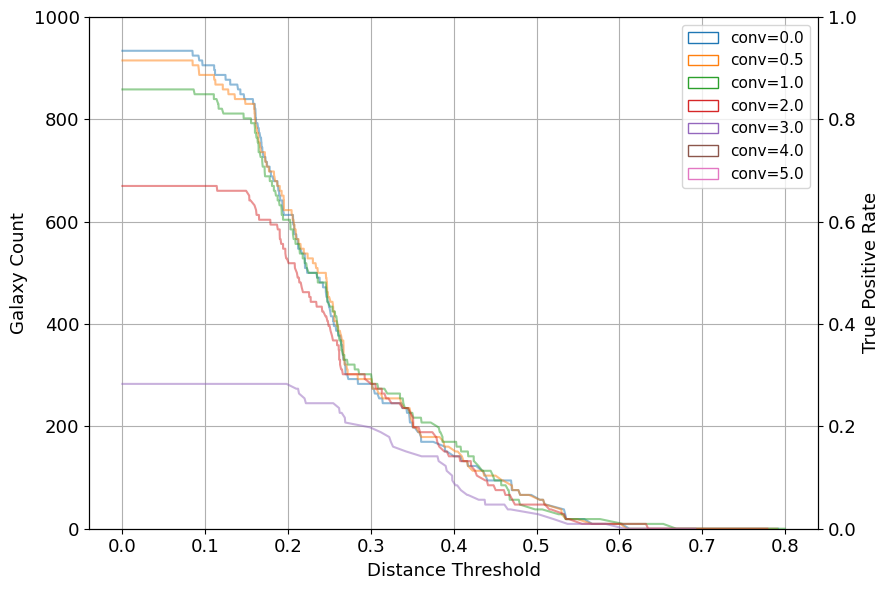

In [12]:
# TPR vs distances

df = f150w_Table_joined.copy()

distance = df['distance_as']
has_psf = df['has_psf']
convolution = df['convolution']

# Define ground truth from defined pairs
df['is_pair'] = np.isin(df['id'], pairs) & (df['has_psf'] == False) & (df['convolution'] == 0.0)
zero_dist = (df['is_pair'] == False) & (df['has_psf'] == False)
df['distance_as'][zero_dist] = 0.0

fig, ax = plt.subplots(figsize=(9, 6))
axt = ax.twinx()

conv_values = np.unique(df['convolution'])

# making a histogram of distances measured for each conv value 
for conv in conv_values:
    mask_psf = (df['has_psf'] == True) & (df['convolution'] == conv)
    dist_psf = (df['distance_as'][mask_psf]) 

    ax.hist(
        dist_psf,
        histtype='step',
        label=f'conv={conv}',
        bins=np.arange(0,max(df['distance_as']),5)
        )
    ax.set_ylabel('Galaxy Count',fontsize=13)
    ax.legend(fontsize=11)

# plotting tpr vs distances
for conv in convolutions:
    # mask to isolate images with psf and ground truth sample
    mask_psf    = (df['has_psf'] == True)  & (df['convolution'] == conv)    # images with PSF
    mask_nopsf  = (df['has_psf'] == False) & (df['convolution'] == 0.0)     # ground truth

    dist_psf = (df['distance_as'][mask_psf])      # distances with PSF
    is_pair_nopsf = df['is_pair'][mask_nopsf]   # ground truth pairs
    
    if len(dist_psf) == 0:
        continue
    
    # get TPR
    thresholds, _ = cumulative(dist_psf)
    __, tpr_list = get_tpr(dist_psf, is_pair_nopsf)

    axt.plot(thresholds, tpr_list, label=f'Conv={conv}',zorder=5, alpha=0.5)


# ax.set_xlim(-2,52)
ax.set_ylim(0,1000)
ax.set_xlabel('Distance Threshold',fontsize=13)
axt.set_ylim(0,1)
axt.set_ylabel('True Positive Rate',fontsize=13)
# axt.legend(fontsize=11)
ax.grid(True)
plt.tight_layout()
plt.savefig(f'{img_path}/tpr_distance.png')
# plt.show()


findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Fo

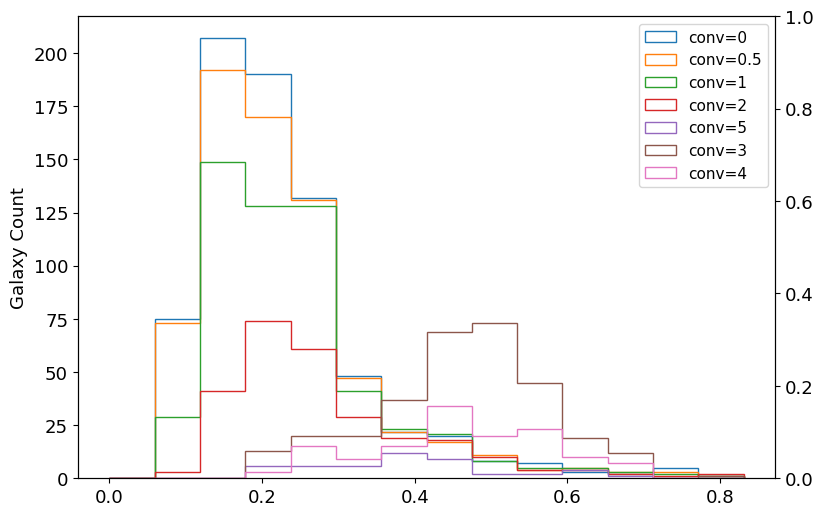

In [13]:
# Histogram showing only non-zero distances for psf images

df = f150w_Table_joined.copy()

distance = df['distance_as']
has_psf = df['has_psf']
convolution = df['convolution']

# Define ground truth from defined pairs - true = matching pair id, no psf, conv=0.0
df['is_pair'] = np.isin(df['id'], pairs) & (df['has_psf'] == False) & (df['convolution'] == 0.0)
zero_dist = (df['is_pair'] == False) & (df['has_psf'] == False)
df['distance_as'][zero_dist] = 0.0

fig, ax = plt.subplots(figsize=(9, 6))
axt = ax.twinx()

conv_values = np.unique(df['convolution'])
conv_values = (0, 0.5, 1, 2, 5, 3, 4)

# making a histogram of distances measured for each conv value 
for conv in conv_values:
    mask_psf = (df['has_psf'] == True) & (df['convolution'] == conv) & (df['distance_as'] != 0)
    dist_psf = (df['distance_as'][mask_psf]) 

    ax.hist(dist_psf,histtype='step',label=f'conv={conv}',bins=np.linspace(0,max(df['distance_as']),15))
    ax.set_ylabel('Galaxy Count',fontsize=13)
    ax.legend(fontsize=11)

findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Font family 'cm' not found.
findfont: Fo

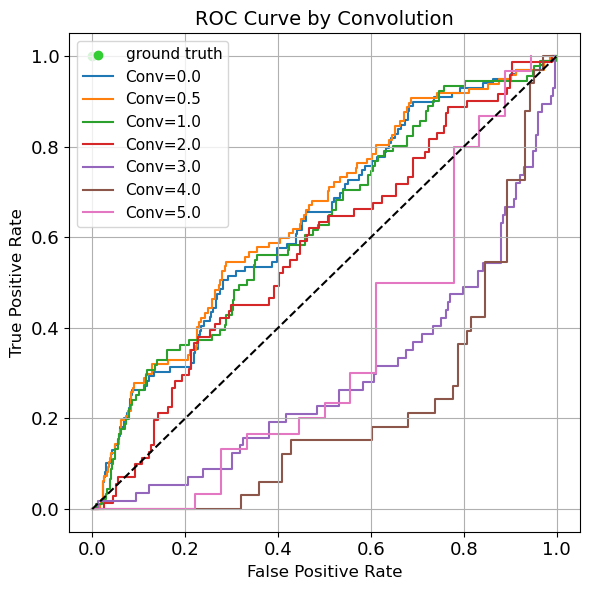

In [14]:
# -------------------------------
# --- ONE PANEL ROC - TESTING --- 
# -------------------------------
tbl = f150w_Table_joined.copy() # copy data

# define gt pair column
tbl['is_pair'] = np.isin(tbl['id'], pairs) & (tbl['has_psf'] == False)

# mask no-psf non-pairs - set distance to zero
zero_dist = (tbl['is_pair'] == False) & (tbl['has_psf'] == False)
tbl['distance_as'][zero_dist] = 0.0

conv_values = np.unique(tbl['convolution'])

plt.figure(figsize=(6, 6))

mask_nopsf = tbl['has_psf'] == False
is_pair_nopsf = tbl['is_pair'][mask_nopsf]
predicted_pair = is_pair_nopsf

TP = ((predicted_pair == 1) & (is_pair_nopsf == 1)).sum()  # True Positives
FP = ((predicted_pair == 1) & (is_pair_nopsf == 0)).sum()  # False Positives
TN = ((predicted_pair == 0) & (is_pair_nopsf == 0)).sum()  # True Negatives
FN = ((predicted_pair == 0) & (is_pair_nopsf == 1)).sum()  # False Negatives

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0  # True Positive Rate
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0  # False Positive Rate

plt.scatter(FPR, TPR, c='limegreen',label='ground truth')

for conv in conv_values:
    mask_psf = (tbl['has_psf'] == True) & (tbl['convolution'] == conv) # experimenet case 
    mask_nopsf = (tbl['has_psf'] == False) & (tbl['convolution'] == 0.0) # ground truth case

    # only including psf pairs
    mask_psf = (
    (tbl['has_psf'] == True) &
    (tbl['convolution'] == conv) &
    (tbl['distance_as'] != 0)
    )
    selected_ids = tbl['id'][mask_psf]
    mask_nopsf = (
    (tbl['has_psf'] == False) &
    (tbl['convolution'] == 0.0) &
    np.isin(tbl['id'], selected_ids)
    )   

    tbl_psf = tbl[mask_psf]
    tbl_nopsf = tbl[mask_nopsf]

    tbl_psf.sort('id')
    tbl_nopsf.sort('id')

    # Get row indices for objects using np.where
    psf_indices = np.where(mask_psf)[0]
    nopsf_indices = np.where(mask_nopsf)[0]
    
    is_pair_nopsf = tbl_nopsf['is_pair']      # by-eye ground truth 
    lum_FUV_log = np.log10(tbl_psf['lumFUV'])  # luminosities

    dist_psf = tbl_psf['distance_as']      # distances 
    thresholds, _ = cumulative(dist_psf)   # distance thresholds

    assert len(dist_psf) == len(is_pair_nopsf)

    tpr_list = []
    fpr_list = []
    threshold_list = []

    for t in thresholds:
        predicted_pair = (dist_psf > t).astype(np.int8)

        TP = ((predicted_pair == 1) & (is_pair_nopsf == 1)).sum()  # True Positives
        FP = ((predicted_pair == 1) & (is_pair_nopsf == 0)).sum()  # False Positives
        TN = ((predicted_pair == 0) & (is_pair_nopsf == 0)).sum()  # True Negatives
        FN = ((predicted_pair == 0) & (is_pair_nopsf == 1)).sum()  # False Negatives

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0  # True Positive Rate
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0  # False Positive Rate
        
        # independently update pair list
        is_pair_psf = tbl['is_pair'][mask_psf].copy()
        detected_pair_indices = np.where(predicted_pair == 1)[0]
        is_pair_psf[detected_pair_indices] = True

        tpr_list.append(TPR)
        fpr_list.append(FPR)
        threshold_list.append(t) 

    plt.plot(fpr_list, tpr_list, label=f'Conv={conv}',zorder=1)

    assert np.all(np.diff(fpr_list[::-1]) >= 0)
    assert np.all(np.diff(tpr_list[::-1]) >= 0)
    
    # if conv == 2: 
    #     for i in range(len(tpr_list)):
    #         if tpr_list[i] != 1.0:
                # print(tpr_list[i],fpr_list[i],threshold_list[i])

# 1:1 line
plt.plot([0, 1], [0, 1], 'k--')

# figure settings 
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve by Convolution', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

look at objects in convolution 5 <br>
manual tpr and fpr <br>
another diagnostic plot? - another combo of tpr, fpr, tnr, fnr <br>


/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_52430/1612975446.py:153: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  uvlf = ax.errorbar(


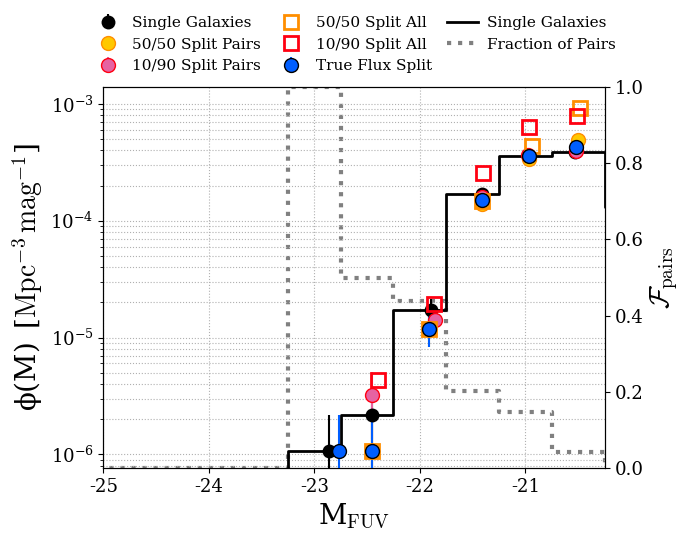

In [15]:
# ============================================================ #
#           GLOBAL FONT SETTINGS (Math Font Everywhere)        #
# ============================================================ #

plt.rcParams['mathtext.fontset'] = 'cm'        # Computer Modern math font
plt.rcParams['font.family'] = 'serif'          # Use serif for all non-math text
plt.rcParams['font.serif'] = ['CMU Serif', 'DejaVu Serif']

plt.rcParams['axes.unicode_minus'] = False     # Proper minus signs
plt.rcParams['mathtext.default'] = 'regular'   # Consistent regular math font

# ================================================ #
#   FUV Luminosity Function + Fraction of Pairs    #
# ================================================ #

# ----- Select GT from Catalog -----
mask_nopsf = ((df['has_psf'] == False) & (df['convolution'] == 0.0))
lum_FUV = df[mask_nopsf]['lumFUV']

# ----- Split Luminosity for Pair Galaxies -----
lum_sets = {
    'single': [], 
    '5050_pairs': [], '1090_pairs': [],
    '5050_all': [], '1090_all': [], 
    'split': [],
    }

for row in df[mask_nopsf]:
    lum_sets['single'].append(row['lumFUV'])

    # 50/50 flux split
    lum_sets['5050_all'].extend([row['lumFUV'] * 0.5, row['lumFUV'] * 0.5])
    # 10/90 flux split
    lum_sets['1090_all'].extend([row['lumFUV'] * 0.1, row['lumFUV'] * 0.9])

    if row['is_pair']:
        lum_sets['split'].extend([
            row['lumFUV'] * row['flux_ratio'],
            row['lumFUV'] * (1 - row['flux_ratio'])
        ])

        lum_sets['5050_pairs'].extend([row['lumFUV'] * 0.5, row['lumFUV'] * 0.5])
        lum_sets['1090_pairs'].extend([row['lumFUV'] * 0.1, row['lumFUV'] * 0.9])

    else:
        lum_sets['split'].append(row['lumFUV'])
        lum_sets['5050_all'].append(row['lumFUV'])
        lum_sets['1090_all'].append(row['lumFUV'])
        lum_sets['5050_pairs'].append(row['lumFUV'])
        lum_sets['1090_pairs'].append(row['lumFUV'])

# ----- Convert luminosity to magnitude -----
M_FUV = {}
for key, lum_values in lum_sets.items():
    lum_log = np.log10(lum_values)
    M_FUV[key] = 51.63 - 2.5 * lum_log

# ----- Volume of sample ----- 
len_sample = len(lum_FUV)
len_catalog = len(catalog)
h = 0.7
L_box = 400 / h
V_box = L_box**3
V_eff = V_box * (len_sample / len_catalog)

# ----- Construct bins -----
bin_width = 0.5
bin_phase = 0.75

M_min = -26
M_max = -15

start = np.floor((M_min - bin_phase) / bin_width) * bin_width + bin_phase

# bins_M = np.arange(start, M_max + bin_width, bin_width)
# bin_centers_M = 0.5 * (bins_M[:-1] + bins_M[1:])

bins_M = np.arange(-26.25, -14.75, 0.5)  # magnitude bins
bin_centers_M = 0.5 * (bins_M[:-1] + bins_M[1:])
bin_width_M = bins_M[1] - bins_M[0]

# ----- Compute bin median magnitudes -----
median_key = 'single'   # to compute medians consistently


# ----- Calculate UVLF -----
phi_M = {}
phi_err_M = {}

labels = {
    'single': 'Single Galaxies', 'split': 'True Flux Split',
    '5050_all': '50/50 Split All', '1090_all': '10/90 Split All',
    '5050_pairs': '50/50 Split Pairs', '1090_pairs': '10/90 Split Pairs'
}
mfc = {
    'single': 'k', 'split': '#005EFF',
    '5050_all':'None',  '1090_all': 'None',
    '5050_pairs': '#FFC800', '1090_pairs': '#E663A2',
}
mec = {
    'single': 'None', 'split': 'k',
    '5050_all': "#FF8E00", '1090_all': "#FF0011",
    '5050_pairs': "#FF8E00", '1090_pairs': "#FF0011"
}
markers = {
    'single': 'o', 'split': 'o',
    '5050_all': 's', '1090_all': 's',
    '5050_pairs': "o", '1090_pairs': "o"
}
linestyles = {
    'single': '-', 'split': '-', 
    '5050_all': '--', '1090_all': '--'
    }
linewidths = {
    'single': 2, 'split': 1, 
    '5050_all': 2, '1090_all': 2, ''
    '5050_pairs': 1, '1090_pairs': 1
    }

# ----- Fraction of pairs -----
mask_pairs = df[mask_nopsf]['is_pair']
M_single = M_FUV['single']
fraction_pairs = []

for i in range(len(bins_M)-1):
    bin_mask = (M_single >= bins_M[i]) & (M_single < bins_M[i+1])
    if np.sum(bin_mask) > 0:
        fraction_pairs.append(np.mean(mask_pairs[bin_mask]))
    else:
        fraction_pairs.append(0.0)

# ----- Plot UVLF + Pair Fractions -----
fig, ax = plt.subplots(figsize=(7, 5.5))

bin_widths = np.diff(bins_M)

legend_handles = []
for key in lum_sets.keys():
    bin_medians = []
    M_vals = M_FUV[key]

    for i in range(len(bins_M)-1):
        mask = (M_vals >= bins_M[i]) & (M_vals < bins_M[i+1])
        if np.any(mask):
            bin_medians.append(np.median(M_vals[mask]))
        else:
            bin_medians.append(np.nan)

    N_M, _ = np.histogram(M_FUV[key], bins=bins_M)
    phi_M[key] = N_M / (V_eff * bin_widths)
    phi_err_M[key] = np.sqrt(N_M) / (V_eff * bin_widths)

    uvlf = ax.errorbar(
        bin_medians, phi_M[key], yerr=phi_err_M[key], label=labels[key],
        fmt='o', color=mfc[key], markeredgecolor=mec[key], marker=markers[key],
        markeredgewidth=linewidths[key], alpha=1, markersize=10, zorder=5
    )
    legend_handles.append(uvlf)
    
# -------------------- SAVE SPLIT UVLF FOR REUSE -------------------- #

UVLF_SPLIT = {
    'M_median': np.array(bin_medians),   # from key == 'split'
    'phi': phi_M['split'],
    'phi_err': phi_err_M['split'],
    'bins': bins_M,
    'bin_centers': bin_centers_M,
    'V_eff': V_eff
}

single_ladies, = ax.step(
    bin_centers_M, phi_M['single'], where='mid',
    color=mfc['single'], linestyle=linestyles['single'], 
    linewidth=linewidths['single'], zorder=2,
    label=labels['single']
)
legend_handles.append(single_ladies)


# ---------------------- AXIS FONTS (Math Font) ---------------------- #

ax.set_yscale('log')

# math-font ticks
ax.yaxis.set_major_formatter(LogFormatterMathtext())

ax.set_xlabel(r'$M_{\mathrm{FUV}}$', fontsize=20)
ax.set_ylabel(r'$\phi(M)\;\;[\mathrm{Mpc^{-3}\,mag^{-1}}]$', fontsize=20)
ax.set_xlim(-21+bin_phase, -25)
# ax.set_ylim(10**(-7.2), 10**(-3.5))
ax.grid(True, which='both', ls=':')
ax.invert_xaxis()
ax.patch.set_alpha(0.0) # makes background transparent

# ----- Pair fraction axis -----
ax2 = ax.twinx()
ax2.set_zorder(ax.get_zorder() - 1) # plots axis 2 first

pair_frac, = ax2.step(
    bin_centers_M, fraction_pairs, ':', where='mid',
    color='grey', label='Fraction of Pairs', linewidth=3, zorder=1
)
legend_handles.append(pair_frac)

ax2.set_ylim(0, 1)
ax2.set_ylabel(r'$\mathcal{F}_{\mathrm{pairs}}$', fontsize=20)

# legend
leg = ax.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=3,
    fontsize=11,
    handlelength=2,
    handletextpad=0.6,
    columnspacing=1.0,
    markerscale=1,
    frameon=False
)

# Ensure right-axis tick labels use math font too (auto)
plt.tight_layout()
plt.show()

### Updates 11/12: (COMPLETE)
add 50/50 and 10/90 split for all galaxies (not just pairs) <br>
make plot prettier <br>
    update fonts to latex font <br>
    fancy f for fraction $\mathcal{F or f_{\text{pairs}}}$ <br>

different binning phases - center on 0.0 and 0.5, then half phase off <br>
different binning sizes, generally 0.5 in width <br>
change linewidth <br>
change linecolors - find color palettes on adobe <br>
maybe only dots for splits <br>
keep grids until I can't anymore <br>
put dot in median x value of each bin <br>

In [16]:
# columns -----
mask_nopsf = ((df['has_psf'] == False) & (df['convolution'] == 0.0))
mask_pairs = df[mask_nopsf]['is_pair']
# print(mask_pairs)
M_single = 51.63 - 2.5 * np.log10(df[mask_nopsf]['lumFUV'])  # Convert lum to M_FUV

# ----- Define magnitude bins -----
bin_width = 0.5           # Width of bins
bin_phase = 0.0          # Shift (0.0: edges at .0/.5 ; 0.25 shifts by 0.25 mag, etc.)

M_min = -26.25
M_max = -14.75

# Start from the nearest edge ending in .0 or .5
start = np.floor((M_min - bin_phase) / bin_width) * bin_width + bin_phase

bins_M = np.arange(start, M_max + bin_width, bin_width)
bin_centers_M = 0.5 * (bins_M[:-1] + bins_M[1:])

# ----- Compute and print number and fraction of pairs -----
print(f"{'Bin Center (M_FUV)':>20} | {'# Galaxies':>10} | {'# Pairs':>8} | {'Fraction':>10}")
print("-"*60)

for i in range(len(bins_M)-1):
    # galaxies within this magnitude bin
    bin_mask = (M_single >= bins_M[i]) & (M_single < bins_M[i+1])
    
    n_total = np.sum(bin_mask)
    if n_total > 0:
        n_pairs = np.sum(mask_pairs[bin_mask])
        frac = n_pairs / n_total
    else:
        n_pairs = 0
        frac = 0.0

    print(f"{bin_centers_M[i]:>20.2f} | {n_total:>10d} | {n_pairs:>8d} | {frac:>10.2f}")


  Bin Center (M_FUV) | # Galaxies |  # Pairs |   Fraction
------------------------------------------------------------
              -26.25 |          0 |        0 |       0.00
              -25.75 |          0 |        0 |       0.00
              -25.25 |          0 |        0 |       0.00
              -24.75 |          0 |        0 |       0.00
              -24.25 |          0 |        0 |       0.00
              -23.75 |          0 |        0 |       0.00
              -23.25 |          0 |        0 |       0.00
              -22.75 |          1 |        1 |       1.00
              -22.25 |          5 |        2 |       0.40
              -21.75 |         60 |       16 |       0.27
              -21.25 |        258 |       52 |       0.20
              -20.75 |        383 |       29 |       0.08
              -20.25 |        255 |        6 |       0.02
              -19.75 |         37 |        0 |       0.00
              -19.25 |          0 |        0 |       0.00
           

/opt/anaconda3/envs/bt_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3858: RuntimeWarning: Mean of empty slice.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/opt/anaconda3/envs/bt_env/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(0.9176341192994327), np.float64(0.4951669608604124), np.float64(0.6572689884955873), np.float64(0.6409385591805528), np.float64(0.4547899995815665), np.float64(0.6463146838450222), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]


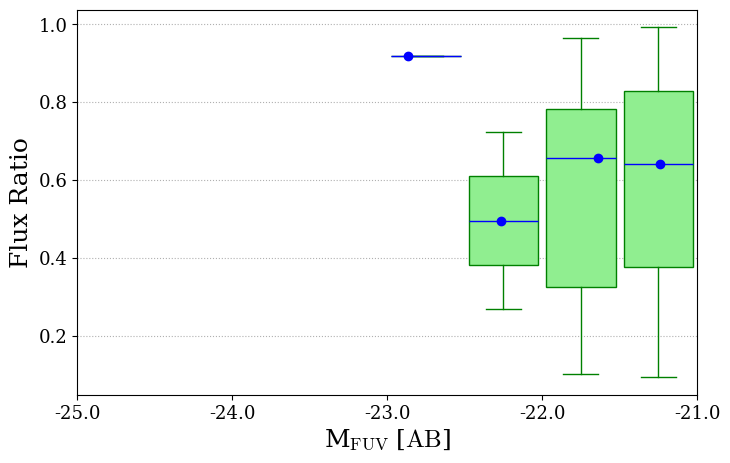

In [17]:
plt.figure(figsize=(8,5))

# Only consider galaxies in pairs from ground truth
mask_pairs = mask_nopsf & (df['is_pair'] == True)
M_single = 51.63 - 2.5 * np.log10(df[mask_pairs]['lumFUV'])  # Magnitudes
flux_ratios = df[mask_pairs]['flux_ratio']

# construct bins
bin_width = 0.5           # Width of bins
bin_phase = 0.0        # Shift (0.0: edges at .0/.5 ; 0.25 shifts by 0.25 mag, etc.)

M_min = -26.25
M_max = -14.75

# Start from the nearest edge ending in .0 or .5
start = np.floor((M_min - bin_phase) / bin_width) * bin_width + bin_phase

bins_M = np.arange(start, M_max + bin_width, bin_width)
bin_centers_M = 0.5 * (bins_M[:-1] + bins_M[1:])

bin_medians = []

for i in range(len(bins_M)-1):
    mask = (M_single >= bins_M[i]) & (M_single < bins_M[i+1])
    if np.any(mask):
        bin_medians.append(np.median(M_single[mask]))
    else:
        bin_medians.append(np.nan)    # or skip

# Bin flux ratios
flux_ratio_bins = []
flux_medians = []
for i in range(len(bins_M)-1):
    bin_mask = (M_single >= bins_M[i]) & (M_single < bins_M[i+1])
    flux_ratio_bins.append(np.array(flux_ratios[bin_mask]))
    flux_medians.append(np.median(flux_ratios[bin_mask]))
print(flux_medians)

# Remove empty bins
positions = [c for c, f in zip(bin_centers_M[::-1], flux_ratio_bins[::-1]) if len(f) > 0]
data = [f for f in flux_ratio_bins[::-1] if len(f) > 0]

# Boxplot
plt.boxplot(data, positions=positions, widths=0.9*bin_width, patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='green'),
            medianprops=dict(color='blue'),
            whiskerprops=dict(color='green'),
            capprops=dict(color='green'),
            flierprops=dict(marker='o', color='green', alpha=0.5))

valid_medians = [m for m, f in zip(bin_medians[::-1], flux_ratio_bins[::-1]) if len(f) > 0]
flux_medians_filtered = [m for m, f in zip(flux_medians[::-1], flux_ratio_bins[::-1]) if len(f) > 0]

plt.scatter(valid_medians, flux_medians_filtered, color='blue', zorder=3)


plt.xlabel(r'$M_{\mathrm{FUV}}\ [\mathrm{AB}]$')
plt.ylabel('Flux Ratio')
plt.xlim(-25, -21)
plt.grid(True, axis='y', ls=':')
plt.xticks(np.linspace(-25, -21, 5), [f'{x:.1f}' for x in np.linspace(-25, -21, 5)])
plt.show()


/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_52430/691153719.py:132: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax.annotate(


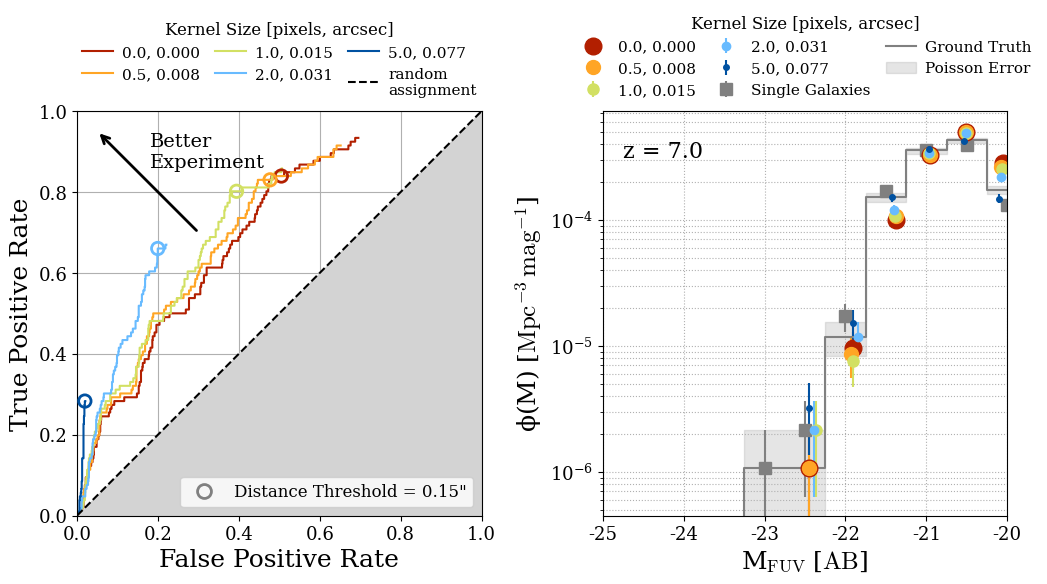

In [18]:
# ================= ROC Curve & UVLF ================= #
# ===== All Convolutions + One Distance Threshold ==== #
# ==================================================== #


# ----- GLOBAL FONT SETTINGS (Math Font Everywhere) -----       
plt.rcParams['mathtext.fontset'] = 'cm'        # Computer Modern math font
plt.rcParams['font.family'] = 'serif'          
plt.rcParams['font.serif'] = ['CMU Serif', 'DejaVu Serif']

plt.rcParams['axes.unicode_minus'] = False     # Proper minus signs
plt.rcParams['mathtext.default'] = 'regular'   # Consistent regular math font

df = f150w_Table.copy()
# Create is_pair column - True for ground truth
df['is_pair'] = np.isin(df['id'], pairs) & (df['has_psf'] == False)

# Set zero distances for non-pairs (no PSF)
zero_dist = (df['is_pair'] == False) & (df['has_psf'] == False)
df['distance_as'][zero_dist] = 0.0
distance_threshold = 0.15

conv_values = [0.0, 0.5, 1.0, 2.0, 5.0]
colors = ['#B21F00','#FFA525','#D2E063','#68BBFF','#0051A1']
sizes = [12,10,8,6,4]

# ------------------ MAKE FIGURE ------------------ #
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(1, 2, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

ax1.set_box_aspect(1)
ax2.set_box_aspect(1)

# ------------------- ROC CURVES ------------------- #
ax = ax1

roc_results = {}
leg2_handles = []

for idx,conv in enumerate(conv_values):
    mask_psf = (df['has_psf'] == True) & (df['convolution'] == conv)
    mask_nopsf = (df['has_psf'] == False) & (df['convolution'] == 0.0)

    # ADD MASK HERE
    # KEEP TRACK OF SAMPLE SIZE
    dist_psf = df['distance_as'][mask_psf]
    is_pair_nopsf = df['is_pair'][mask_nopsf]

    thresholds, _ = cumulative(dist_psf)

    tpr_list, fpr_list, threshold_list = [], [], []

    for t in thresholds:
        predicted_pair = (dist_psf > t).astype(np.int8)

        TP = ((predicted_pair == 1) & (is_pair_nopsf == 1)).sum()
        FP = ((predicted_pair == 1) & (is_pair_nopsf == 0)).sum()
        TN = ((predicted_pair == 0) & (is_pair_nopsf == 0)).sum()
        FN = ((predicted_pair == 0) & (is_pair_nopsf == 1)).sum()

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        tpr_list.append(TPR)
        fpr_list.append(FPR)
        threshold_list.append(t)

    roc_results[conv] = {
        'TPR': tpr_list, 
        'FPR': fpr_list, 
        'thresholds': threshold_list
        }
    roc, = ax.step(
        fpr_list, tpr_list, 
        label=f'{conv}, {conv*0.0155:.3f}', 
        color=colors[idx], 
        zorder=1,
        where='post'
        )
    leg2_handles.append(roc)

    thresholds_arr = np.array(threshold_list)
    idx_thresh = np.argmin(np.abs(thresholds_arr - distance_threshold)) # idx of closest thresh to 10.0

    # Extract TPR and FPR at that point
    tpr_thresh = tpr_list[idx_thresh]
    fpr_thresh = fpr_list[idx_thresh]
    thresh = thresholds_arr[idx_thresh]

    # Plot a point at that threshold
    ax.scatter(
        fpr_thresh, tpr_thresh,
        s=80,
        edgecolors=colors[idx],
        linewidths=2,
        facecolors='none',
        marker='o',
        zorder=3,
    )

# 1:1 line (random assignment)
black_dash, = ax.plot([0, 1], [0, 1], 'k--', label='random\nassignment')
leg2_handles.append(black_dash)

# gray shading under 1:1 line
x = np.linspace(0, 1, 500)
ax.fill_between(
    x,
    0,          # lower boundary
    x,          # upper boundary = 1:1 line
    color='lightgray',
    alpha=1.0,
    zorder=1
)

# better experiment arrow
ax.annotate(
    '',
    xy=(0.05, 0.95),        # arrow tip (near 0,1 so it doesn't clip)
    xytext=(0.3, 0.7),    # text location
    textcoords='axes fraction',
    arrowprops=dict(arrowstyle='->',lw=2),
    fontsize=14,
    ha='center',
    va='center'
)

# better experiment text
ax.annotate(
    'Better\nExperiment',
    xy=(0.18, 0.9),    # text location
    textcoords='axes fraction',
    fontsize=14,
    ha='left',
    va='center'
)

# ------------------ GROUND TRUTH ------------------ #
# mask_nopsf = (df['has_psf'] == False)
# is_pair_nopsf = df['is_pair'][mask_nopsf]
# predicted_pair = is_pair_nopsf

# TP = ((predicted_pair == 1) & (is_pair_nopsf == 1)).sum()
# FP = ((predicted_pair == 1) & (is_pair_nopsf == 0)).sum()
# TN = ((predicted_pair == 0) & (is_pair_nopsf == 0)).sum()
# FN = ((predicted_pair == 0) & (is_pair_nopsf == 1)).sum()

# TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
# FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

# plot GT point (tpr=1, fpr=0)
# gt = ax.scatter(FPR, TPR, 
#            c='limegreen', 
#            marker='s',
#            s=100,
#            edgecolors='green',
#            label='Ground Truth')

# ------------------ PLOTTING ------------------ #
# --- LEGEND 1 ---
open_circle = mlines.Line2D(
    [], [], linestyle='none',
    marker='o', markersize=10,
    markerfacecolor='none', markeredgecolor='gray',
    markeredgewidth=2, alpha=1, 
    label='Distance Threshold = 0.15"'
    )
leg1 = ax.legend(
    handles=[open_circle],
    loc=4,
    fontsize=12
)
ax.add_artist(leg1)

# --- LEGEND 2 ---
leg2 = ax.legend(
    handles=leg2_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=3,
    fontsize=11,            # ↓ text size
    title='Kernel Size [pixels, arcsec]',
    title_fontsize=12,
    handlelength=2,       # ↓ line length
    handletextpad=0.6,      # ↓ gap between handle & text
    columnspacing=1.0,      # ↓ spacing between columns
    markerscale=0.8,        # ↓ marker size
    frameon=False
)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
# ax.set_title('ROC Curve by Convolution')
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_axisbelow(True)
ax.grid(True, zorder=0)

# ---------------- UVLF FOR SPECIFIC THRESHOLD ---------------- #
ax = ax2

distance_threshold = 0.15

# --- Ground Truth (gray histogram) ---
mask_gt = (df['has_psf'] == False) & (df['convolution'] == 0.0)
lum_FUV_gt = np.log10(df['lumFUV'][mask_gt])
M_FUV_gt = 51.63 - 2.5 * lum_FUV_gt

len_sample = len(lum_FUV_gt)
len_catalog = len(catalog)
h = 0.7
L_box = 400 / h
V_box = L_box**3
V_eff = V_box * (len_sample / len_catalog)

bins_M = np.arange(-26.25, -14.75, 0.5)  # magnitude bins
bin_centers_M = 0.5 * (bins_M[:-1] + bins_M[1:])
bin_width_M = bins_M[1] - bins_M[0]

N_gt_M, _ = np.histogram(M_FUV_gt, bins=bins_M)
phi_gt_M = N_gt_M / (V_eff * bin_width_M)
phi_err_gt_M = np.sqrt(N_gt_M)/(V_eff * bin_width_M)

upper = phi_gt_M + phi_err_gt_M
lower = phi_gt_M - phi_err_gt_M

# # ----- Compute bin medians -----
# bin_medians_M = []

# for i in range(len(bins_M) - 1):
#     in_bin = (M_FUV_gt >= bins_M[i]) & (M_FUV_gt < bins_M[i + 1])
#     if np.any(in_bin):
#         bin_medians_M.append(np.median(M_FUV_gt[in_bin]))
#     else:
#         bin_medians_M.append(np.nan)

# bin_medians_M = np.array(bin_medians_M)

# ----- SINGLE GALAXIES AS ERRORBARS -----
single_gals = ax.errorbar(
    bin_centers_M, phi_gt_M, 
    yerr=phi_err_gt_M,
    fmt='s',
    markersize=8,
    label='Single Galaxies',
    color='gray'
    )

# ----- SINGLE GALAXIES AS A STEP FUNCTION -----
# single_gals, = ax.step(
#     bin_centers_M, phi_gt_M, 
#     where='mid', 
#     label='Single Galaxies',
#     color='gray'
#     )
# poisson_err = ax.fill_between(
#     bin_centers_M, 
#     lower, upper, 
#     step='mid', 
#     alpha=0.2, 
#     color='gray',
#     label='Poisson Error'
#     )

# ----- Loop through all convolution values -----
leg2_handles = []
for idx,conv in enumerate(conv_values):

    mask_psf = (df['has_psf'] == True) & (df['convolution'] == conv)
    dist_psf = df['distance_as'][mask_psf]
    lumFUV_psf = df['lumFUV'][mask_psf]
    flux_ratio_psf = df['flux_ratio'][mask_psf]

    predicted_pair = (dist_psf >= distance_threshold)

    lumFUV_split = []
    for i in range(len(lumFUV_psf)):
        if predicted_pair[i]:
            lumFUV_split.append(lumFUV_psf[i] * flux_ratio_psf[i])
            lumFUV_split.append(lumFUV_psf[i] * (1 - flux_ratio_psf[i]))
        else:
            lumFUV_split.append(lumFUV_psf[i])

    lumFUV_split = np.log10(lumFUV_split)
    M_FUV_pair = 51.63 - 2.5 * np.array(lumFUV_split)

    N_pair_M, _ = np.histogram(M_FUV_pair, bins=bins_M)
    phi_pair_M = N_pair_M / (V_eff * bin_width_M)
    phi_err_pair_M = np.sqrt(N_pair_M) / (V_eff * bin_width_M)

    # --- Compute bin medians ---
    bin_medians_M = []

    for i in range(len(bins_M) - 1):
        in_bin = (M_FUV_pair >= bins_M[i]) & (M_FUV_pair < bins_M[i + 1])
        if np.any(in_bin):
            bin_medians_M.append(np.median(M_FUV_pair[in_bin]))
        else:
            bin_medians_M.append(np.nan)

    bin_medians_M = np.array(bin_medians_M)

    # plt.step(bin_centers_M, phi_pair_M, where='mid', label=f'Conv={conv}',c)
    uvlf = ax.errorbar(
        bin_medians_M,  # change to bin_centers_M if desired
        phi_pair_M, 
        yerr=phi_err_pair_M, 
        fmt='o',
        color=colors[idx],
        label=rf'{conv}, {conv*0.0155:.3f}',
        ms=sizes[idx]
        )
    leg2_handles.append(uvlf)
leg2_handles.append(single_gals)
# leg2_handles.append(poisson_err)

# ----- ADD TRUE SPLIT UVLF ----- #

# ----- TRUE SPLIT AS ERRORBAR -----
# true_split = ax.errorbar(
#     UVLF_SPLIT['M_median'],
#     UVLF_SPLIT['phi'],
#     yerr=UVLF_SPLIT['phi_err'],
#     fmt='o',
#     color='#005EFF',
#     markeredgecolor='k',
#     markersize=9,
#     linewidth=1.5,
#     label='True Flux Split (GT)',
#     zorder=10
# )

# ----- TRUE SPLIT AS STEP FUNCTION -----
true_split, = ax.step(
    bin_centers_M, 
    UVLF_SPLIT['phi'],
    where='mid', 
    label='Ground Truth',
    color='gray'
    )
lower = UVLF_SPLIT['phi'] - UVLF_SPLIT['phi_err']   # lower error
upper = UVLF_SPLIT['phi'] + UVLF_SPLIT['phi_err']   # upper error
poisson_err = ax.fill_between(
    bin_centers_M,
    lower,
    upper,
    step='mid',
    alpha=0.2,
    color='gray',
    label='Poisson Error'
)
leg2_handles.append(true_split)
leg2_handles.append(poisson_err)

# ----- LABEL REDSHIFT OF UVLF -----
ax.annotate(
    'z = 7.0',
    xy=(0.05, 0.9),    # text location
    xycoords='axes fraction',
    fontsize=16,
    ha='left',
    va='center'
)

ax.set_yscale('log')
ax.set_xlabel(r'$M_{\mathrm{FUV}}\ [\mathrm{AB}]$')
ax.set_ylabel(r'$\phi(M)\ [\mathrm{Mpc^{-3}\,mag^{-1}}]$')
# ax.set_title(f'FUV Luminosity Function')
ax.grid(True, which='both', ls=':')
ax.set_xlim(-25,-20)

# second legend
leg2 = ax.legend(
    handles=leg2_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=3,
    fontsize=11,
    title='Kernel Size [pixels, arcsec]',
    title_fontsize=12,
    handlelength=2,
    handletextpad=0.6,
    columnspacing=1.0,
    markerscale=1,
    frameon=False
)
# ax.add_artist(leg2)

# plt.tight_layout()
plt.show()


In [19]:
# ASSUME CONSTANT ANGULAR SIZE

z_center = 7.0
z_low = 6.5
z_high = 7.5

# perpendicular length (z=7)
h = cosmo.h
L_perp = (400 / h) * u.Mpc   # comoving Mpc

# Convert comoving width of box to angle
D_M_z7 = cosmo.comoving_transverse_distance(z_center)   # used for converting btwn physical size and angle
print("comoving transverse distance:", D_M_z7)
theta = (L_perp / D_M_z7) * u.rad                       # angle (box width/D_M)
print("Angular size:", theta.to(u.deg))

# Cross section area (square field)
area_z7 = theta**2
print("Solid angle:", area_z7.to(u.sr))

# Compute shell comoving volume
V_inner = cosmo.comoving_volume(z_low)
V_outer = cosmo.comoving_volume(z_high)

V_shell = (area_z7 / (4 * np.pi * u.sr)) * (V_outer - V_inner)
V_box = (400/0.7)**3 * u.Mpc**3

print("Light pyramid volume:", V_shell.to(u.Mpc**3))
print("Box size:", V_box)

print("difference in volume:", V_box-V_shell)


# ASSUME CONSTANT COMOVING LENGTH

z1 = 6.5
z2 = 7.5

chi1 = cosmo.comoving_distance(z1)
chi2 = cosmo.comoving_distance(z2)

delta_chi = (chi2 - chi1).to(u.Mpc)

# perpendicular length (z=7)
h = cosmo.h
L_perp = (400 / h) * u.Mpc   # comoving Mpc

V = L_perp**2 * delta_chi

print("Light pyramid volume:", V.to(u.Mpc**3))

comoving transverse distance: 8811.560795105375 Mpc
Angular size: 3.844127540951607 deg
Solid angle: 0.004501428039168312 sr
Light pyramid volume: 122404434.46325141 Mpc3
Box size: 186588921.28279886 Mpc3
difference in volume: 64184486.819547445 Mpc3
Light pyramid volume: 122616228.54919156 Mpc3


In [20]:
L_box = 400 / 0.7  # Mpc, comoving box length
z = 7.0

DM = cosmo.comoving_transverse_distance(z)  # Mpc
theta_rad = L_box / DM.value                # radians

# Convert to arcminutes
theta_arcmin = theta_rad * (180/np.pi) * 60
print(f"Box angular size: {theta_arcmin:.2f} arcmin")

# Survey area in arcmin^2
area_arcmin2 = theta_arcmin**2
print(f"Effective survey area: {area_arcmin2:.2f} arcmin^2")


Box angular size: 222.94 arcmin
Effective survey area: 49701.10 arcmin^2


In [21]:
# Define mapping function
def f(x,y):
    a, b = np.polyfit(x, y, 1)
    print("a =", a)
    print("b =", b)
    return a*x + b


bin width 0.25
71052
redshift= 7
0 7
[-26.25 -26.   -25.75 -25.5  -25.25 -25.   -24.75 -24.5  -24.25 -24.
 -23.75 -23.5  -23.25 -23.   -22.75 -22.5  -22.25 -22.   -21.75 -21.5
 -21.25 -21.   -20.75 -20.5  -20.25 -20.   -19.75 -19.5  -19.25 -19.
 -18.75 -18.5  -18.25 -18.   -17.75 -17.5  -17.25 -17.   -16.75 -16.5
 -16.25 -16.   -15.75 -15.5  -15.25 -15.  ]
0.25
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.14375000e-08 0.00000000e+00 4.28750000e-08
 8.57500000e-08 8.14625000e-07 3.23706250e-06 1.20907500e-05
 3.73870000e-05 9.42178125e-05 2.07150562e-04 3.32967250e-04
 3.92906500e-04 3.23384687e-04 1.18870937e-04 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000

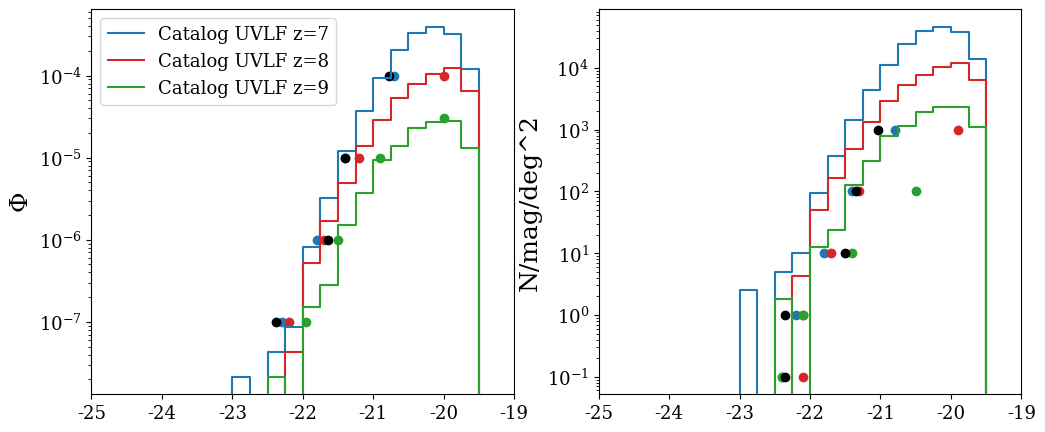

In [22]:
# --- UVLF FOR DIFFERENT REDSHIFTS ---

# BINS 
bins_M = np.arange(-26.25, -14.75, 0.25)  # magnitude bins
bin_centers_M = 0.5 * (bins_M[:-1] + bins_M[1:])
bin_width_M = bins_M[1] - bins_M[0]
print("bin width", bin_width_M)

# VOLUME
h = 0.7
L_box = 400 / h
V_box = L_box**3

# COMOVING DISTANCES FOR z=7,8,9
D_C = [358.3, 300.4, 256.5]
targets_UVLF = np.array([1e-4, 1e-5, 1e-6, 1e-7])
targets_N    = np.array([1e3,1e2,1e1,1e0,1e-1])
colors = ['tab:blue', 'tab:red', 'tab:green']


fig, axes = plt.subplots(1,2,figsize=(12,5),sharex=True)

for i, z in enumerate([7, 8, 9]):
    mask = (catalog['redshift'] == z) #& (catalog['lum_FUV'] > 4.92 * 10**28.5)
    lum_FUV = np.log10(catalog['lum_FUV'][mask])
    M_FUV = 51.63 - 2.5 * lum_FUV

    M = 51.63 - 2.5 * lum_FUV #+ 2.5 * np.log10(1+7)
    print(len(M))

    print('redshift=', z)
    print('==================')

    # UVLF
    N_M, _ = np.histogram(M, bins=bins_M)
    phi_M = N_M / (V_box * bin_width_M)
    print(i,z)
    print(bins_M)
    print(bin_width_M)
    print(phi_M)
    print('------------')
    # phi_M = phi_M / 5
    phi_err_M = np.sqrt(N_M)/(V_box * bin_width_M)

    N_z = N_M * D_C[i] / (L_box * bin_width_M)
    # N_z = N_z / 10

    # # finding values to correct
    # for t in targets_UVLF:
    #     idx = np.nanargmin(np.abs(phi_M.value - t))
    #     print(f"{t:.0e}:")
    #     print(f"   Closest phi = {phi_M[idx]:.3e}")
    #     print(f"   M = {bin_centers_M[idx]:.3f}")
    # print('---------------------')
    # for t in targets_N:
    #     idx = np.nanargmin(np.abs(N_z - t))
    #     print(f"{t:.0e}:")
    #     print(f"   N_z = {N_z[idx]:.3e}")
    #     print(f"   M = {bin_centers_M[idx]:.3f}")

    # plot uvlf
    axes[0].step(
        bin_centers_M, 
        phi_M,
        where='mid', 
        label=f'Catalog UVLF z={z}',
        color=colors[i]
        )

    # plot number density
    axes[1].step(
        bin_centers_M, 
        N_z,
        where='mid', 
        label=f'Number Density z={z}',
        color=colors[i]
        )

print(V_box)
print(V_shell)

axes[0].scatter([-20.7, -21.4, -21.8, -22.3], [1e-4,1e-5,1e-6,1e-7], color='tab:blue')    # z=7
axes[0].scatter([-20, -21.2, -21.7, -22.2],   [1e-4,1e-5,1e-6,1e-7], color='tab:red')    # z=8
axes[0].scatter([-20, -20.9, -21.5, -21.95],  [3e-5,1e-5,1e-6,1e-7], color='tab:green')         # z=9

# linear fit to UVLF z=7
x = np.array([-21.375, -22.625, -23.125, -24.625])
y = np.array([-20.7, -21.4, -21.8, -22.3])
axes[0].scatter(f(x,y), [1e-4,1e-5,1e-6,1e-7], color='k')

axes[0].set_xlim(-25,-19)
axes[0].set_yscale('log')
axes[0].set_ylabel(r"$\Phi$")
axes[0].legend()

axes[1].scatter([-20.8, -21.4, -21.8, -22.2, -22.4], [1e3,1e2,1e1,1e0,1e-1], color='tab:blue')    # z=7
axes[1].scatter([-19.9, -21.3, -21.7, -22.1, -22.1], [1e3,1e2,1e1,1e0,1e-1], color='tab:red')    # z=8
axes[1].scatter([-20.5, -21.4, -22.1, -22.4],        [1e2,1e1,1e0,1e-1], color='tab:green')        # z=9

# linear fit to N_z z=7
x = np.array([-21.875, -22.875, -23.375, -26.125, -26.125])
y = np.array([-20.8, -21.4, -21.8, -22.2, -22.4])
axes[1].scatter(f(x,y), [1e3, 1e2,1e1,1e0,1e-1], color='k')

axes[1].set_ylabel(r"N/mag/deg^2")
axes[1].set_yscale('log')

In [23]:
df = f150w_Table.copy()
conv_value = 1.0

# Create is_pair column - True for ground truth
df['is_pair'] = np.isin(df['id'], pairs) & (df['has_psf'] == False)

# Set zero distances for non-pairs (no PSF)
zero_dist = (df['is_pair'] == False) & (df['has_psf'] == False)
df['distances'][zero_dist] = 0.0

# split into two 
tbl_psf = df[(df['has_psf'] == True) & (df['convolution'] == conv_value)]
tbl_nopsf = df[(df['has_psf'] == False) & (df['convolution'] == 0.0)]

# algn by ID
ids_psf = tbl_psf['id']
ids_nopsf = tbl_nopsf['id']

common_ids = np.intersect1d(ids_psf, ids_nopsf)

mask_psf_common = np.isin(ids_psf, common_ids)
mask_nopsf_common = np.isin(ids_nopsf, common_ids)

tbl_psf = tbl_psf[mask_psf_common]
tbl_nopsf = tbl_nopsf[mask_nopsf_common]

# enforce same order
order = np.argsort(tbl_psf['id'])
tbl_psf = tbl_psf[order]

order = np.argsort(tbl_nopsf['id'])
tbl_nopsf = tbl_nopsf[order]

assert np.all(tbl_psf['id'] == tbl_nopsf['id'])

/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_52430/2372762186.py:77: RuntimeWarning: invalid value encountered in divide
  (phi_err_gt_M / phi_gt_M)**2 +
/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_52430/2372762186.py:88: RuntimeWarning: invalid value encountered in divide
  (phi_err_by_conv[conv] / phi_by_conv[conv])**2 +
/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_52430/2372762186.py:156: RuntimeWarning: invalid value encountered in divide
  (UVLF_SPLIT['phi_err'] / UVLF_SPLIT['phi'])**2
/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_52430/2372762186.py:166: RuntimeWarning: invalid value encountered in divide
  (phi_err_by_conv[conv] / phi_by_conv[conv])**2 +


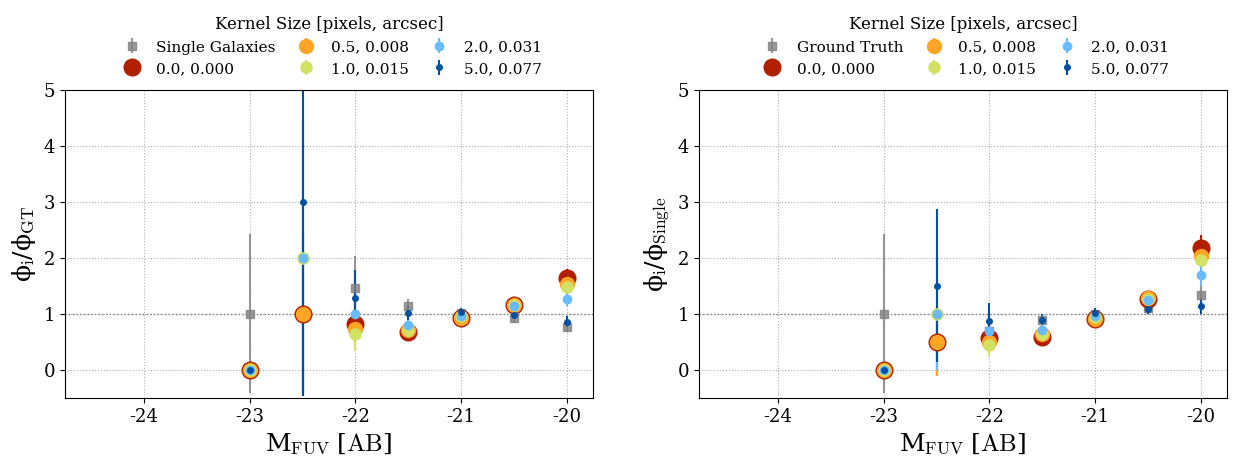

In [24]:
# ------------ UVLF RATIOS ------------

distance_threshold = 0.15 # arcsec
conv_values = [0.0, 0.5, 1.0, 2.0, 5.0]
colors = ['#B21F00','#FFA525','#D2E063','#68BBFF','#0051A1']
sizes = [12,10,8,6,4]

# --- UVLF SINGLE GALAXIES ---
mask_gt = (df['has_psf'] == False) & (df['convolution'] == 0.0)
lum_FUV_gt = np.log10(df['lumFUV'][mask_gt])
M_FUV_gt = 51.63 - 2.5 * lum_FUV_gt

len_sample = len(lum_FUV_gt)
len_catalog = len(catalog)
h = 0.7
L_box = 400 / h
V_box = L_box**3
V_eff = V_box * (len_sample / len_catalog)

bins_M = np.arange(-26.25, -14.75, 0.5)  # magnitude bins
bin_centers_M = 0.5 * (bins_M[:-1] + bins_M[1:])
bin_width_M = bins_M[1] - bins_M[0]

N_gt_M, _ = np.histogram(M_FUV_gt, bins=bins_M)
phi_gt_M = N_gt_M / (V_eff * bin_width_M)
phi_err_gt_M = np.sqrt(N_gt_M)/(V_eff * bin_width_M)

# --- UVLF CONVOLUTIONS ---
phi_by_conv = {}
phi_err_by_conv = {}
for idx,conv in enumerate(conv_values):
    mask_psf = (df['has_psf'] == True) & (df['convolution'] == conv)    # set of 1000 
    dist_psf = df['distance_as'][mask_psf]                              # dist in as
    lumFUV_psf = df['lumFUV'][mask_psf]                                 # luminosities
    flux_ratio_psf = df['flux_ratio'][mask_psf]                         # flux ratios
    predicted_pair = (dist_psf >= distance_threshold)                   # list of T/F for pairs

    # SPLITTING THE LUMINOSITY
    lumFUV_split = []
    for i in range(len(lumFUV_psf)):
        if predicted_pair[i]:
            lumFUV_split.append(lumFUV_psf[i] * flux_ratio_psf[i])
            lumFUV_split.append(lumFUV_psf[i] * (1 - flux_ratio_psf[i]))
        else:
            lumFUV_split.append(lumFUV_psf[i])

    # CONVERT FROM LUM TO MAG
    lumFUV_split = np.log10(lumFUV_split)
    M_FUV_pair = 51.63 - 2.5 * np.array(lumFUV_split)

    # COMPUTE UVLF
    N_pair_M, _ = np.histogram(M_FUV_pair, bins=bins_M)
    phi_pair_M = N_pair_M / (V_eff * bin_width_M)
    phi_err_pair_M = np.sqrt(N_pair_M) / (V_eff * bin_width_M)

    phi_by_conv[conv] = phi_pair_M
    phi_err_by_conv[conv] = phi_err_pair_M

# Ground Truth UVLF (TRUE FLUX SPLIT)


# -------------------------------------------------------------------------------------
fig, axes = plt.subplots(1,2,figsize=(15, 4))

ax = axes[0]

# --- reference line ---
ax.axhline(1.0, color='gray', linestyle=':', lw=1)

# --- extract ground truth ---
phi_ref = UVLF_SPLIT['phi']
phi_ref_safe = np.where(phi_ref > 0, phi_ref, np.nan) # eliminate nans

# --- single galaxies ratio ---
ratio_gt = phi_gt_M / phi_ref_safe
ratio_single_err = ratio_gt * np.sqrt(
    (phi_err_gt_M / phi_gt_M)**2 +
    (UVLF_SPLIT['phi_err'] / phi_ref_safe)**2
)

# --- ratios for each convolution ---
ratio_by_conv = {}
ratio_err_by_conv = {}

for conv in conv_values:
    ratio_by_conv[conv] = phi_by_conv[conv] / phi_ref_safe
    ratio_err_by_conv[conv] = ratio_by_conv[conv] * np.sqrt(
        (phi_err_by_conv[conv] / phi_by_conv[conv])**2 +
        (UVLF_SPLIT['phi_err'] / phi_ref_safe)**2
    )

leg2_handles = []

# --- ground truth ---
phi_single = ax.errorbar(
    bin_centers_M,
    ratio_gt,
    yerr=ratio_single_err,
    fmt='s',
    color='gray',
    label='Single Galaxies',
    alpha=0.8
)
leg2_handles.append(phi_single)

# --- convolutions ---
for idx, conv in enumerate(conv_values):
    phi_conv = ax.errorbar(
        bin_centers_M,
        ratio_by_conv[conv],
        yerr=ratio_err_by_conv[conv],
        fmt='o',
        color=colors[idx],
        ms=sizes[idx],
        label=rf'{conv}, {conv*0.0155:.3f}'
    )
    leg2_handles.append(phi_conv)

# --- legend ---
leg = ax.legend(
    handles=leg2_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=3,
    fontsize=11,
    title='Kernel Size [pixels, arcsec]',
    title_fontsize=12,
    handlelength=2,
    handletextpad=0.6,
    columnspacing=1.0,
    markerscale=1,
    frameon=False
)

ax.set_xlabel(r'$M_{\mathrm{FUV}}\ [\mathrm{AB}]$')
ax.set_ylabel(r'$\phi_{\mathrm{i}} / \phi_{\mathrm{GT}}$')
ax.set_yscale('linear')
ax.set_xlim(-24.75, -19.75)
ax.set_ylim(-0.5,5)
ax.grid(True, ls=':')

# -------------------------------------------------------------------------------------
ax = axes[1]

# --- reference line ---
ax.axhline(1.0, color='gray', linestyle=':', lw=1)

# --- extract ground truth ---
phi_ref = phi_gt_M
phi_ref_safe = np.where(phi_ref > 0, phi_ref, np.nan)

# --- single galaxies ratio ---
ratio_gt = UVLF_SPLIT['phi'] / phi_ref_safe
ratio_gt_err= ratio_gt * np.sqrt(
    (phi_err_gt_M / phi_ref_safe)**2 +
    (UVLF_SPLIT['phi_err'] / UVLF_SPLIT['phi'])**2
)

# --- ratios for each convolution ---
ratio_by_conv = {}
ratio_err_by_conv = {}

for conv in conv_values:
    ratio_by_conv[conv] = phi_by_conv[conv] / phi_ref_safe
    ratio_err_by_conv[conv] = ratio_by_conv[conv] * np.sqrt(
        (phi_err_by_conv[conv] / phi_by_conv[conv])**2 +
        (phi_err_gt_M  / phi_ref_safe)**2
    )

leg2_handles = []

# --- ground truth ---
phi_single = ax.errorbar(
    bin_centers_M,
    ratio_gt,
    yerr=ratio_gt_err,
    fmt='s',
    color='gray',
    label='Ground Truth',
    alpha=0.8
)
leg2_handles.append(phi_single)

# --- convolutions ---
for idx, conv in enumerate(conv_values):
    phi_conv = ax.errorbar(
        bin_centers_M,
        ratio_by_conv[conv],
        yerr=ratio_err_by_conv[conv],
        fmt='o',
        color=colors[idx],
        ms=sizes[idx],
        label=rf'{conv}, {conv*0.0155:.3f}'
    )
    leg2_handles.append(phi_conv)

# --- legend ---
leg = ax.legend(
    handles=leg2_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=3,
    fontsize=11,
    title='Kernel Size [pixels, arcsec]',
    title_fontsize=12,
    handlelength=2,
    handletextpad=0.6,
    columnspacing=1.0,
    markerscale=1,
    frameon=False
)
ax.set_xlabel(r'$M_{\mathrm{FUV}}\ [\mathrm{AB}]$')
ax.set_ylabel(r'$\phi_{\mathrm{i}} / \phi_{\mathrm{Single}}$')
ax.set_yscale('linear')
ax.set_xlim(-24.75, -19.75)
ax.set_ylim(-0.5,5)
ax.grid(True, ls=':')

plt.show()


/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_52430/1451286632.py:230: RuntimeWarning: divide by zero encountered in log10
  lumFUV_split = np.log10(lumFUV_split)


0.5


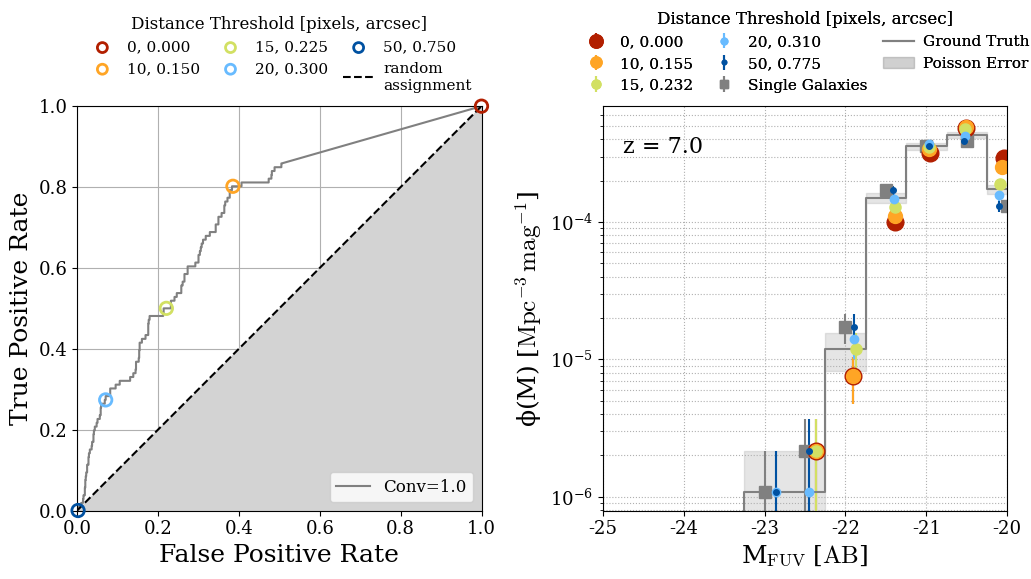

In [25]:
# ================= ROC Curve & UVLF ================= #
# ==== One Convolution + Five Distance Thresholds ==== #
# ==================================================== #

df = f150w_Table.copy()
# Create is_pair column - True for ground truth
df['is_pair'] = np.isin(df['id'], pairs) & (df['has_psf'] == False)

# Set zero distances for non-pairs (no PSF)
zero_dist = (df['is_pair'] == False) & (df['has_psf'] == False)
df['distances'][zero_dist] = 0.0

distance_thresholds = [0,10,15,20,50]
conv_value = 1.0
colors = ['#B21F00','#FFA525','#D2E063','#68BBFF','#0051A1']
sizes = [12,10,8,6,4]

# ------------------ MAKE FIGURE ------------------ #
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(1, 2, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

ax1.set_box_aspect(1)
ax2.set_box_aspect(1)

# ------------------- ROC CURVES ------------------- #
ax = ax1
mask_psf = (df['has_psf'] == True) & (df['convolution'] == conv_value)
mask_nopsf = (df['has_psf'] == False) & (df['convolution'] == 0.0)

dist_psf = tbl_psf['distances']
thresholds, _ = cumulative(dist_psf)
is_pair_nopsf = tbl_nopsf['is_pair']

tpr_list, fpr_list, threshold_list = [], [], []
for t in thresholds:
    predicted_pair = (dist_psf >= t).astype(np.int8)

    TP = ((predicted_pair == 1) & (is_pair_nopsf == 1)).sum()
    FP = ((predicted_pair == 1) & (is_pair_nopsf == 0)).sum()
    TN = ((predicted_pair == 0) & (is_pair_nopsf == 0)).sum()
    FN = ((predicted_pair == 0) & (is_pair_nopsf == 1)).sum()

    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

    tpr_list.append(TPR)
    fpr_list.append(FPR)
    threshold_list.append(t)

thresholds_arr = np.array(threshold_list)

leg1_handles = []
leg2_handles = []
for idx,dist in enumerate(distance_thresholds):
    idx_thresh = np.argmin(np.abs(thresholds_arr - dist)) # idx of closest value to the threshold

    # Extract TPR and FPR at each threshold
    tpr_thresh = tpr_list[idx_thresh]
    fpr_thresh = fpr_list[idx_thresh]
    thresh = thresholds_arr[idx_thresh]

    # Plot a point at that threshold
    circle = ax.scatter(
        fpr_thresh, tpr_thresh,
        s=80,
        edgecolors=colors[idx],
        facecolors='none',
        marker='o',
        linewidth=2,
        zorder=3,
        label=f'{dist}, {dist*0.015:.3f}'
    )
    circle.set_clip_on(False)
    
    leg2_handles.append(circle) # add to legend

# plot the roc curve in gray
roc, = ax.plot(
    fpr_list, tpr_list, 
    color='gray', 
    label=f'Conv={conv_value}', 
    zorder=1)

leg1_handles.append(roc) # add to legend

# 1:1 line (random assignment)
black_dash, = ax.plot([0, 1], [0, 1], 'k--', label='random\nassignment')
leg2_handles.append(black_dash)

# gray shading under 1:1 line
x = np.linspace(0, 1, 500)
ax.fill_between(
    x,
    0,          # lower boundary
    x,          # upper boundary = 1:1 line
    color='lightgray',
    alpha=1.0,
    zorder=1
)

# ------------------ GROUND TRUTH ------------------ #
# mask_nopsf = (df['has_psf'] == False)
# is_pair_nopsf = df['is_pair'][mask_nopsf]
# predicted_pair = is_pair_nopsf

# TP = ((predicted_pair == 1) & (is_pair_nopsf == 1)).sum()
# FP = ((predicted_pair == 1) & (is_pair_nopsf == 0)).sum()
# TN = ((predicted_pair == 0) & (is_pair_nopsf == 0)).sum()
# FN = ((predicted_pair == 0) & (is_pair_nopsf == 1)).sum()

# TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
# FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

# gt = ax.scatter(FPR, TPR, 
#            c='limegreen', 
#            marker='s',
#            s=100,
#            edgecolors='green',
#            label='Ground Truth')

# ------------------ PLOTTING ------------------ #
# --- LEGEND 1 ---

leg1 = ax.legend(
    handles=leg1_handles,
    loc=4,
    fontsize=12
)
ax.add_artist(leg1)

leg2 = ax.legend(
    handles=leg2_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=3,
    fontsize=11,            # ↓ text size
    title='Distance Threshold [pixels, arcsec]',
    title_fontsize=12,
    handlelength=2,       # ↓ line length
    handletextpad=0.6,      # ↓ gap between handle & text
    columnspacing=1.0,      # ↓ spacing between columns
    markerscale=0.8,        # ↓ marker size
    frameon=False
)

ax.set_xlabel('False Positive Rate',)
ax.set_ylabel('True Positive Rate',)
ax.set_xlim(0,1)
ax.set_ylim(0,1)
# ax.set_title('ROC Curve by Convolution', )
ax.set_axisbelow(True)
ax.grid(True)


# ---------------- UVLF FOR SPECIFIC CONVOLUTION ---------------- #

ax = ax2

# --- Ground Truth (gray histogram) ---
mask_gt = (df['has_psf'] == False) & (df['convolution'] == 0.0)
lum_FUV_gt = np.log10(df['lumFUV'][mask_gt])
M_FUV_gt = 51.63 - 2.5 * lum_FUV_gt

# simulation params
len_sample = len(lum_FUV_gt)
len_catalog = len(catalog)
h = 0.7
L_box = 400 / h
V_box = L_box**3
V_eff = V_box * (len_sample / len_catalog)

bins_M = np.arange(-26.25, -14.75, 0.5)  # magnitude bins
bin_width = (bins_M[1]-bins_M[0])
print(bin_width)
bin_centers_M = 0.5 * (bins_M[:-1] + bins_M[1:])

N_gt_M, _ = np.histogram(M_FUV_gt, bins=bins_M)
phi_gt_M = N_gt_M / (V_eff * bin_width_M)
phi_err_gt_M = np.sqrt(N_gt_M)/(V_eff * bin_width_M)

upper = phi_gt_M + phi_err_gt_M
lower = phi_gt_M - phi_err_gt_M

# ----- SINGLE GALAXIES AS ERRORBARS -----
single_gals = ax.errorbar(
    bin_centers_M, phi_gt_M, 
    yerr=phi_err_gt_M,
    fmt='s',
    markersize=8,
    label='Single Galaxies',
    color='gray'
    )

# ----- SINGLE GALAXIES AS STEP FUNCTION -----
# gt_uvlf, = ax.step(
#     bin_centers_M, phi_gt_M, 
#     where='mid', 
#     label='Single Galaxies',
#     color='gray')
# poisson_err = ax.fill_between(
#     bin_centers_M, 
#     lower, upper,
#     step='mid', 
#     alpha=0.2, 
#     color='gray',
#     label='Poisson Error')


# --- Loop through all distance thresholds ---
mask_psf = (df['has_psf'] == True) & (df['convolution'] == conv_value)
dist_psf = df['distances'][mask_psf]
lumFUV_psf = df['lumFUV'][mask_psf]
flux_ratio_psf = df['flux_ratio'][mask_psf]

leg2_handles = []
for idx, dist in enumerate(distance_thresholds):
    predicted_pair = (dist_psf >= dist)

    lumFUV_split = []
    for i in range(len(lumFUV_psf)):
        if predicted_pair[i]:
            lumFUV_split.append(lumFUV_psf[i] * flux_ratio_psf[i])
            lumFUV_split.append(lumFUV_psf[i] * (1 - flux_ratio_psf[i]))
        else:
            lumFUV_split.append(lumFUV_psf[i])

    lumFUV_split = np.log10(lumFUV_split)
    M_FUV_pair = 51.63 - 2.5 * np.array(lumFUV_split)

    N_pair_M, _ = np.histogram(M_FUV_pair, bins=bins_M)
    phi_pair_M = N_pair_M / (V_eff * bin_width_M)
    phi_err_pair_M = np.sqrt(N_pair_M) / (V_eff * bin_width_M)

    # --- Compute bin medians ---
    bin_medians_M = []

    for i in range(len(bins_M) - 1):
        in_bin = (M_FUV_pair >= bins_M[i]) & (M_FUV_pair < bins_M[i + 1])
        if np.any(in_bin):
            bin_medians_M.append(np.median(M_FUV_pair[in_bin]))
        else:
            bin_medians_M.append(np.nan)

    bin_medians_M = np.array(bin_medians_M)

    # plt.step(bin_centers_M, phi_pair_M, where='mid', label=f'Distance={dist}')
    uvlf = ax.errorbar(
        bin_medians_M,  # change to bin_centers_M if desired
        phi_pair_M, 
        yerr=phi_err_pair_M, 
        fmt='o',
        color=colors[idx],
        ms=sizes[idx],
        label=f'{dist}, {dist*0.0155:.3f}')
    leg2_handles.append(uvlf)
    
# add other handles to legend
leg2_handles.append(single_gals)

# ----- TRUE SPLIT AS STEP FUNCTION -----
true_split, = ax.step(
    bin_centers_M, 
    UVLF_SPLIT['phi'],
    where='mid', 
    label='Ground Truth',
    color='gray'
    )
lower = UVLF_SPLIT['phi'] - UVLF_SPLIT['phi_err']   # lower error
upper = UVLF_SPLIT['phi'] + UVLF_SPLIT['phi_err']   # upper error
poisson_err = ax.fill_between(
    bin_centers_M,
    lower,
    upper,
    step='mid',
    alpha=0.2,
    color='gray',
    label='Poisson Error'
)
leg2_handles.append(true_split)
leg2_handles.append(poisson_err)

ax.annotate(
    'z = 7.0',
    xy=(0.05, 0.9),    # text location
    xycoords='axes fraction',
    fontsize=16,
    ha='left',
    va='center'
)
ax.set_yscale('log')
ax.set_xlabel(r'$M_{\mathrm{FUV}}\ [\mathrm{AB}]$')
ax.set_ylabel(r'$\phi(M)\ [\mathrm{Mpc^{-3}\,mag^{-1}}]$')

leg2 = ax.legend(
    handles=leg2_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=3,
    fontsize=11,            # ↓ text size
    title='Distance Threshold [pixels, arcsec]',
    title_fontsize=12,
    handlelength=2,       # ↓ line length
    handletextpad=0.6,      # ↓ gap between handle & text
    columnspacing=1.0,      # ↓ spacing between columns
    markerscale=0.8,        # ↓ marker size
    frameon=False
)
ax.add_artist(leg2)
ax.grid(True, which='both', ls=':')
ax.set_xlim(-25,-20)
# ax.set_ylim(1e-7, 5e-4)
# plt.tight_layout()
plt.show()


/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_52430/441384525.py:49: RuntimeWarning: divide by zero encountered in log10
  lumFUV_split = np.log10(lumFUV_split)
/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_52430/441384525.py:85: RuntimeWarning: invalid value encountered in divide
  (phi_err_gt_M / phi_gt_M)**2 +
/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_52430/441384525.py:96: RuntimeWarning: invalid value encountered in divide
  (phi_err_by_dist[dist] / phi_by_dist[dist])**2 +
/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_52430/441384525.py:164: RuntimeWarning: invalid value encountered in divide
  (UVLF_SPLIT['phi_err'] / UVLF_SPLIT['phi'])**2
/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_52430/441384525.py:174: RuntimeWarning: invalid value encountered in divide
  (phi_err_by_dist[dist] / phi_by_dist[dist])**2 +


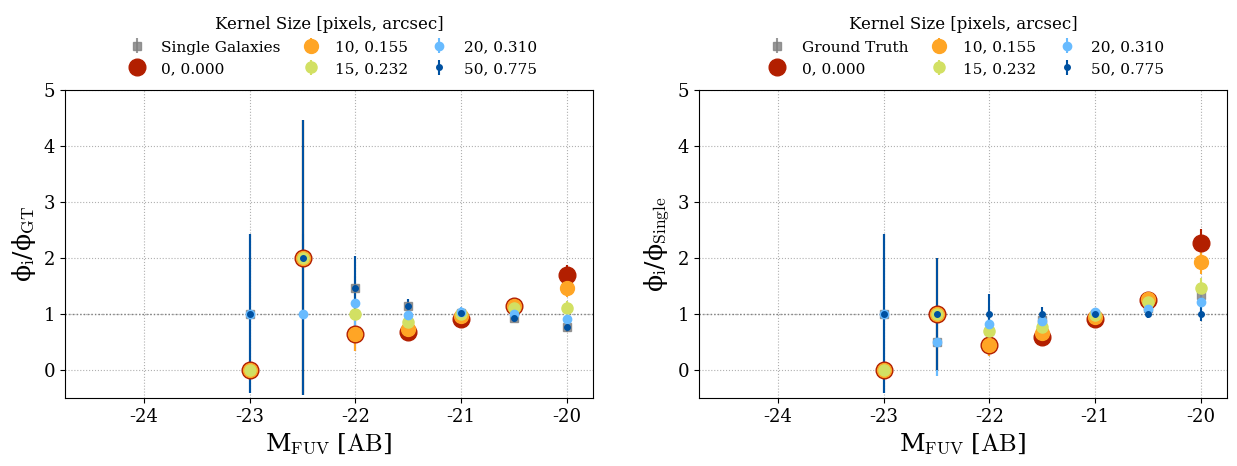

In [26]:
# ------------ UVLF RATIOS ------------

distance_thresholds = np.array([0,10,15,20,50]) # distance in pixels
conv_value = 1.0
colors = ['#B21F00','#FFA525','#D2E063','#68BBFF','#0051A1']
sizes = [12,10,8,6,4]

# --- UVLF SINGLE GALAXIES ---
mask_gt = (df['has_psf'] == False) & (df['convolution'] == 0.0)
lum_FUV_gt = np.log10(df['lumFUV'][mask_gt])
M_FUV_gt = 51.63 - 2.5 * lum_FUV_gt

len_sample = len(lum_FUV_gt)
len_catalog = len(catalog)
h = 0.7
L_box = 400 / h
V_box = L_box**3
V_eff = V_box * (len_sample / len_catalog)

bins_M = np.arange(-26.25, -14.75, 0.5)  # magnitude bins
bin_centers_M = 0.5 * (bins_M[:-1] + bins_M[1:])
bin_width_M = bins_M[1] - bins_M[0]

N_gt_M, _ = np.histogram(M_FUV_gt, bins=bins_M)
phi_gt_M = N_gt_M / (V_eff * bin_width_M)
phi_err_gt_M = np.sqrt(N_gt_M)/(V_eff * bin_width_M)

# --- COMPUTE UVLFS FOR DIFFERENT DIST THRESHOLDS ---
mask_psf = (df['has_psf'] == True) & (df['convolution'] == conv_value)    # mask for conv=1.0 psf true
dist_psf = df['distances'][mask_psf]                                # distances (pixels)
lumFUV_psf = df['lumFUV'][mask_psf]                                 # luminosities
flux_ratio_psf = df['flux_ratio'][mask_psf]                         # flux ratios

phi_by_dist = {}
phi_err_by_dist = {}
for idx, dist in enumerate(distance_thresholds):
    predicted_pair = (dist_psf >= dist)

    # SPLIT LUMINOSITIES
    lumFUV_split = []
    for i in range(len(lumFUV_psf)):
        if predicted_pair[i]:
            lumFUV_split.append(lumFUV_psf[i] * flux_ratio_psf[i])
            lumFUV_split.append(lumFUV_psf[i] * (1 - flux_ratio_psf[i]))
        else:
            lumFUV_split.append(lumFUV_psf[i])

    # CONVERT FROM LUM TO MAG
    lumFUV_split = np.log10(lumFUV_split)
    M_FUV_pair = 51.63 - 2.5 * np.array(lumFUV_split)

    # COMPUTE UVLF
    N_pair_M, _ = np.histogram(M_FUV_pair, bins=bins_M)
    phi_pair_M = N_pair_M / (V_eff * bin_width_M)
    phi_err_pair_M = np.sqrt(N_pair_M) / (V_eff * bin_width_M)

    phi_by_dist[dist] = phi_pair_M
    phi_err_by_dist[dist] = phi_err_pair_M

# Ground Truth UVLF (TRUE FLUX SPLIT)
# UVLF_SPLIT = {
#     'M_median': np.array(bin_medians), 
#     'phi': phi_M['split'],
#     'phi_err': phi_err_M['split'],
#     'bins': bins_M,
#     'bin_centers': bin_centers_M,
#     'V_eff': V_eff
# }

# -------------------------------------------------------------------------------------
fig, axes = plt.subplots(1,2,figsize=(15, 4))

ax = axes[0]

# --- reference line ---
ax.axhline(1.0, color='gray', linestyle=':', lw=1)

# --- extract ground truth ---
phi_ref = UVLF_SPLIT['phi']
phi_ref_safe = np.where(phi_ref > 0, phi_ref, np.nan)

# --- single galaxies ratio ---
ratio_gt = phi_gt_M / phi_ref_safe
ratio_single_err= ratio_gt * np.sqrt(
    (phi_err_gt_M / phi_gt_M)**2 +
    (UVLF_SPLIT['phi_err'] / phi_ref_safe)**2
)

# --- ratios for each convolution ---
ratio_by_dist = {}
ratio_err_by_dist = {}

for dist in distance_thresholds:
    ratio_by_dist[dist] = phi_by_dist[dist] / phi_ref_safe
    ratio_err_by_dist[dist] = ratio_by_dist[dist] * np.sqrt(
        (phi_err_by_dist[dist] / phi_by_dist[dist])**2 +
        (UVLF_SPLIT['phi_err'] / phi_ref_safe)**2
    )

leg2_handles = []

# --- ground truth ---
phi_single = ax.errorbar(
    bin_centers_M,
    ratio_gt,
    yerr=ratio_single_err,
    fmt='s',
    color='gray',
    label='Single Galaxies',
    alpha=0.8
)
leg2_handles.append(phi_single)

# --- convolutions ---
for idx, dist in enumerate(distance_thresholds):
    phi_dist = ax.errorbar(
        bin_centers_M,
        ratio_by_dist[dist],
        yerr=ratio_err_by_dist[dist],
        fmt='o',
        color=colors[idx],
        ms=sizes[idx],
        label=rf'{dist}, {dist*0.0155:.3f}'
    )
    leg2_handles.append(phi_dist)

# --- legend ---
leg = ax.legend(
    handles=leg2_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=3,
    fontsize=11,
    title='Kernel Size [pixels, arcsec]',
    title_fontsize=12,
    handlelength=2,
    handletextpad=0.6,
    columnspacing=1.0,
    markerscale=1,
    frameon=False
)

ax.set_xlabel(r'$M_{\mathrm{FUV}}\ [\mathrm{AB}]$')
ax.set_ylabel(r'$\phi_{\mathrm{i}} / \phi_{\mathrm{GT}}$')
ax.set_yscale('linear')
ax.set_xlim(-24.75, -19.75)
ax.set_ylim(-0.5,5)
ax.grid(True, ls=':')

# -------------------------------------------------------------------------------------
ax = axes[1]

# --- reference line ---
ax.axhline(1.0, color='gray', linestyle=':', lw=1)

# --- extract ground truth ---
phi_ref = phi_gt_M
phi_ref_safe = np.where(phi_ref > 0, phi_ref, np.nan)

# --- single galaxies ratio ---
ratio_gt = UVLF_SPLIT['phi'] / phi_ref_safe
ratio_gt_err= ratio_gt * np.sqrt(
    (phi_err_gt_M / phi_ref_safe)**2 +
    (UVLF_SPLIT['phi_err'] / UVLF_SPLIT['phi'])**2
)

# --- ratios for each convolution ---
ratio_by_dist = {}
ratio_err_by_dist = {}

for dist in distance_thresholds:
    ratio_by_dist[dist] = phi_by_dist[dist] / phi_ref_safe
    ratio_err_by_dist[dist] = ratio_by_dist[dist] * np.sqrt(
        (phi_err_by_dist[dist] / phi_by_dist[dist])**2 +
        (phi_err_gt_M  / phi_ref_safe)**2
    )

leg2_handles = []

# --- ground truth ---
phi_single = ax.errorbar(
    bin_centers_M,
    ratio_gt,
    yerr=ratio_gt_err,
    fmt='s',
    color='gray',
    label='Ground Truth',
    alpha=0.8
)
leg2_handles.append(phi_single)

# --- distolutions ---
for idx, dist in enumerate(distance_thresholds):
    phi_dist = ax.errorbar(
        bin_centers_M,
        ratio_by_dist[dist],
        yerr=ratio_err_by_dist[dist],
        fmt='o',
        color=colors[idx],
        ms=sizes[idx],
        label=rf'{dist}, {dist*0.0155:.3f}'
    )
    leg2_handles.append(phi_dist)

# --- legend ---
leg = ax.legend(
    handles=leg2_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=3,
    fontsize=11,
    title='Kernel Size [pixels, arcsec]',
    title_fontsize=12,
    handlelength=2,
    handletextpad=0.6,
    columnspacing=1.0,
    markerscale=1,
    frameon=False
)
ax.set_xlabel(r'$M_{\mathrm{FUV}}\ [\mathrm{AB}]$')
ax.set_ylabel(r'$\phi_{\mathrm{i}} / \phi_{\mathrm{Single}}$')
ax.set_yscale('linear')
ax.set_xlim(-24.75, -19.75)
ax.set_ylim(-0.5,5)
ax.grid(True, ls=':')

plt.show()


In [27]:
df = f150w_Table.copy()
df['is_pair'] = np.isin(df['id'], pairs) & (df['has_psf'] == False)
zero_dist = (df['is_pair'] == False) & (df['has_psf'] == False)
df['distance_pkpc'][zero_dist] = 0.0
df['distance_as'][zero_dist] = 0.0

conv = 2.0
threshold = 10 * 0.0155
total_galaxies = 1000

# Masks for convolution = 1.0 (with PSF) and no-PSF baseline
mask_psf = (df['has_psf'] == True) & (df['convolution'] == conv)
mask_nopsf = (df['has_psf'] == False) & (df['convolution'] == 0.0)

# Get distances from convolved images, and true labels from no-PSF data
dist_psf_as = df['distance_as'][mask_psf]
is_pair_nopsf = df['is_pair'][mask_nopsf]

# Predicted pair if distance >= threshold
predicted_pair = (dist_psf >= threshold).astype(int)

# Compute classification outcomes
TP = ((predicted_pair == 1) & (is_pair_nopsf == 1)).sum()
FP = ((predicted_pair == 1) & (is_pair_nopsf == 0)).sum()
TN = ((predicted_pair == 0) & (is_pair_nopsf == 0)).sum()
FN = ((predicted_pair == 0) & (is_pair_nopsf == 1)).sum()

# Convert counts to percentages
TP_pct = 100 * TP / total_galaxies
FP_pct = 100 * FP / total_galaxies
TN_pct = 100 * TN / total_galaxies
FN_pct = 100 * FN / total_galaxies

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0  # True Positive Rate
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0  # False Positive Rate
FNR = FN / (TP + FN) if (TP + FN) > 0 else 0  # True Positive Rate
TNR = TN / (FP + TN) if (FP + TN) > 0 else 0  # False Positive Rate

ax.hist(dist_psf,histtype='step',label=f'conv={conv}',bins=np.arange(0,max(df['distance_pkpc']),5))


# Display
print(f'Conv: {conv}, Threshold: {threshold}')
print(f'TP: {TP} ({TP_pct:.1f}%), TPR: {TPR}')
print(f'FP: {FP} ({FP_pct:.1f}%), FPR: {FPR}')
print(f'TN: {TN} ({TN_pct:.1f}%), TNR: {TNR}')
print(f'FN: {FN} ({FN_pct:.1f}%), FNR: {FNR}')


Conv: 2.0, Threshold: 0.155
TP: 91 (9.1%), TPR: 0.8584905660377359
FP: 452 (45.2%), FPR: 0.5061590145576708
TN: 441 (44.1%), TNR: 0.49384098544232924
FN: 15 (1.5%), FNR: 0.14150943396226415


Summary Statistics:
True Positives (TP): 71 points
False Positives (FP): 197 points
True Negatives (TN): 696 points
False Negatives (FN): 35 points

Distance ranges:
TP distances: 0.11 to 0.63
FP distances: 0.11 to 0.78
TN distances: 0.00 to 0.00
FN distances: 0.00 to 0.00


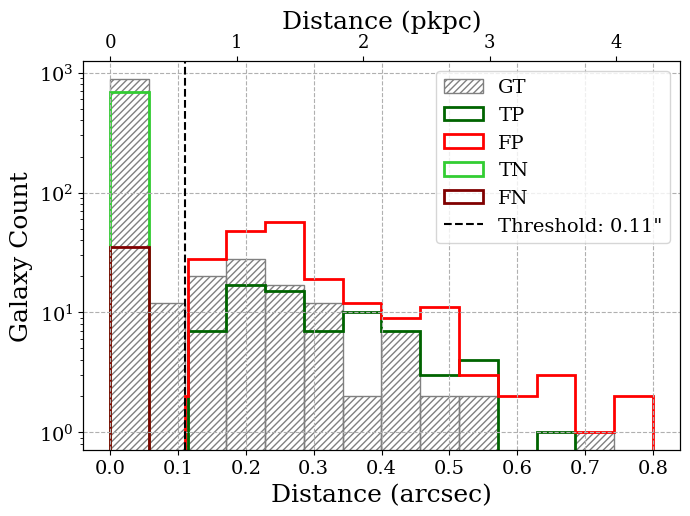

In [28]:
# this one plots rates vs the distance measured for that point
# tnr is all at zero by design - true negatives are given zero distance
# false negatives also get assigned only zero values

df = f150w_Table.copy()
df['is_pair'] = np.isin(df['id'], pairs) & (df['has_psf'] == False)
zero_dist = (df['is_pair'] == False) & (df['has_psf'] == False)
df['distance_pkpc'][zero_dist] = 0.0
df['distance_as'][zero_dist] = 0.0

conv = 2.0
threshold_px = 7.139741303594606
threshold = threshold_px * 0.0155

# Masks for convolved and baseline data
mask_psf = (df['has_psf'] == True) & (df['convolution'] == conv)
mask_nopsf = (df['has_psf'] == False) & (df['convolution'] == 0.0)

# Distance predictions and ground truth labels
dist_psf_as = df['distance_as'][mask_psf] 
dist_nopsf_as = df['distance_as'][mask_nopsf] 
is_pair_nopsf = df['is_pair'][mask_nopsf]

# Convert to arrays
dist_array = dist_psf_as
pred_array = (dist_array >= threshold)

# --- Classify each point ---
tp_mask = (pred_array == 1) & (is_pair_nopsf == 1)
fp_mask = (pred_array == 1) & (is_pair_nopsf == 0)
tn_mask = (pred_array == 0) & (is_pair_nopsf == 0)
fn_mask = (pred_array == 0) & (is_pair_nopsf == 1)

# Get distances for each category
tp_distances = dist_psf_as[tp_mask]
fp_distances = dist_psf_as[fp_mask]
tn_distances = dist_psf_as[tn_mask]
fn_distances = dist_psf_as[fn_mask]
gt_distances = dist_nopsf_as

# --- Plot Histograms ---
fig, ax = plt.subplots(figsize=(7,5))

# Define bins for all histograms
max_dist = max(df['distance_as'])
bins = np.linspace(0, max_dist, 15)

# Insert threshold if it's not already a bin edge
if not np.isclose(threshold, bins).any():
    bins = np.sort(np.append(bins, threshold))

# True Positive Rate Histogram
ax.hist(gt_distances, bins=bins, edgecolor='gray', facecolor='none', label="GT", hatch='/////', zorder=0)
ax.hist(tp_distances, bins=bins, histtype='step', edgecolor='darkgreen', linewidth=2, label="TP", zorder=1)
ax.hist(fp_distances, bins=bins, histtype='step', edgecolor='red'      , linewidth=2, label="FP", zorder=1)
ax.hist(tn_distances, bins=bins, histtype='step', edgecolor='limegreen', linewidth=2, label="TN", zorder=1)
ax.hist(fn_distances, bins=bins, histtype='step', edgecolor='maroon'   , linewidth=2, label="FN", zorder=1)
ax.axvline(threshold, color='black', linestyle='--', label=f'Threshold: {threshold:.2f}"')


# --- Twin x-axis (pkpc) ---
ax_top = ax.twiny()
as_min, as_max = ax.get_xlim()

pkpc_min = as_min / 0.0155 * 0.08311448
pkpc_max = as_max / 0.0155 * 0.08311448

ax_top.set_xlim(pkpc_min, pkpc_max)
ax_top.set_xlabel('Distance (pkpc)')

ax.set_xlabel('Distance (arcsec)')
ax.set_ylabel('Galaxy Count')
ax.tick_params(axis='both', which='major', labelsize=14, labelcolor='k')

ax.set_yscale('log')
ax.legend(fontsize=14)
ax.grid(True, linestyle='--')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig(f'{img_path}/rate_histograms.png')

# --- Print summary statistics ---
print(f"Summary Statistics:")
print(f"True Positives (TP): {len(tp_distances)} points")
print(f"False Positives (FP): {len(fp_distances)} points") 
print(f"True Negatives (TN): {len(tn_distances)} points")
print(f"False Negatives (FN): {len(fn_distances)} points")
print(f"\nDistance ranges:")
print(f"TP distances: {tp_distances.min():.2f} to {tp_distances.max():.2f}")
print(f"FP distances: {fp_distances.min():.2f} to {fp_distances.max():.2f}")
print(f"TN distances: {tn_distances.min():.2f} to {tn_distances.max():.2f}")
print(f"FN distances: {fn_distances.min():.2f} to {fn_distances.max():.2f}")

0.18896021334308793 0.21799188107134493 19
0.18944960190409935 0.2452141574691797 90
0.19482344238872923 0.25296606575528474 112
0.3592547909800431 0.35946576236272054 117
0.4784631298597622 0.5155587040457401 191
0.3179657735191596 0.3511932953554119 199
0.11331829543356572 0.2164682976592352 209
0.41167281046588317 0.44139672641675703 217
0.100608630131686 0.23458820683291517 233
0.4284833915584631 0.4738934027035199 285
0.15983560079175704 0.31330277619098773 326
0.14108311675671306 0.47086044067785227 402
0.15975194306645168 0.3476952892772198 405
0.151730158526506 0.38865088656024005 472
0.1492433701614721 0.5549758971731827 523
0.19292107901605943 0.42793571205054365 530
0.19059960544961208 0.1976030119178437 559
0.08534771450161986 0.264112778696547 568
0.09255731540964532 0.15331868678042077 616
0.09419975172103622 0.4210779699017269 641
0.1387438621213879 0.15947230534475926 657
0.12272787587806037 0.3825207793033432 664
0.09554738909381845 0.3785409147958289 669
0.25878910866

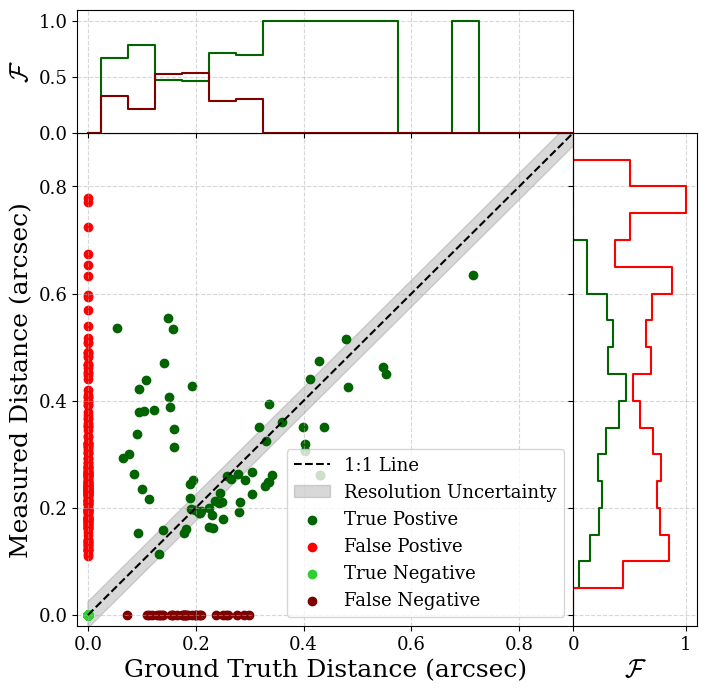

In [29]:
# --- CONSTRUCT FIGURE ---
fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[4, 1],
    height_ratios=[1, 4],
    hspace=0,
    wspace=0
)

ax = fig.add_subplot(gs[1, 0])       # main scatter
ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax)

# --- GET DATA ---
df = f150w_Table.copy()
df['is_pair'] = np.isin(df['id'], pairs) & (df['has_psf'] == False)
zero_dist = (df['is_pair'] == False) & (df['has_psf'] == False)
df['distance_pkpc'][zero_dist] = 0.0
df['distance_as'][zero_dist] = 0.0

conv = 2.0
threshold_px = 7.139741303594606
threshold = threshold_px * 0.0155

# Masks for psf and no psf data
mask_psf = (df['has_psf'] == True) & (df['convolution'] == conv)
mask_nopsf = (df['has_psf'] == False) & (df['convolution'] == 0.0)

# Distance predictions and ground truth labels
dist_psf = df['distance_as'][mask_psf] 
dist_nopsf = df['distance_as'][mask_nopsf] 
is_pair_nopsf = df['is_pair'][mask_nopsf]

# Convert to arrays
pred_array = (dist_psf >= threshold)

# --- Classify each point ---
tp_mask = (pred_array == 1) & (is_pair_nopsf == 1)
fp_mask = (pred_array == 1) & (is_pair_nopsf == 0)
tn_mask = (pred_array == 0) & (is_pair_nopsf == 0)
fn_mask = (pred_array == 0) & (is_pair_nopsf == 1)

tp_distances = dist_psf[tp_mask]
fp_distances = dist_psf[fp_mask]
tn_distances = dist_psf[tn_mask]
fn_distances = dist_psf[fn_mask]

tp_distances_gt = dist_nopsf[tp_mask]
fp_distances_gt = dist_nopsf[fp_mask]
tn_distances_gt = dist_nopsf[tn_mask]
fn_distances_gt = dist_nopsf[fn_mask]

x = np.linspace(0, 5, 500)
y = x
ax.plot(x, y, 'k--', label='1:1 Line')

# Error band: ±1.6 px around the 1:1 line
error = 1.6 * 0.0155 
ax.fill_between(x, y - error, y + error, color='gray', alpha=0.3, label='Resolution Uncertainty')

id_psf = df['id'][mask_psf]
tp_id = id_psf[tp_mask]
for i in range(len(tp_id)):
    if tp_distances[i]/tp_distances_gt[i] > 1:
        print(tp_distances_gt[i],tp_distances[i],tp_id[i])


# --- MAIN AXIS ----
ax.scatter(tp_distances_gt,tp_distances,c='darkgreen',label='True Postive')
ax.scatter(fp_distances_gt,fp_distances,c='red',label='False Postive')
ax.scatter(tn_distances_gt,tn_distances,c='limegreen',label='True Negative')
ax.scatter(fn_distances_gt,fn_distances,c='maroon',label='False Negative')

ax.set_xlabel("Ground Truth Distance (arcsec)")
ax.set_ylabel("Measured Distance (arcsec)")
ax.set_xlim(-0.02,0.9)
ax.set_ylim(-0.02,0.9)
ax.legend(fontsize=13)
ax.grid(True, linestyle='--', alpha=0.5)


# --- BINS FOR MARGINAL HISTOGRAMS ---
bin_width = 0.05   
bin_phase = 0.025

d_min = 0.0
d_max = 1.0

start = np.floor((d_min - bin_phase) / bin_width) * bin_width + bin_phase
bins_dist = np.arange(start, d_max + bin_width, bin_width)
bin_centers = 0.5 * (bins_dist[:-1] + bins_dist[1:])


# --- TOP AXIS ---
# Histogram counts per class
c_tp, _ = np.histogram(tp_distances_gt, bins=bins_dist)
c_fp, _ = np.histogram(fp_distances_gt, bins=bins_dist)
c_tn, _ = np.histogram(tn_distances_gt, bins=bins_dist)
c_fn, _ = np.histogram(fn_distances_gt, bins=bins_dist)

# Total per bin
total = c_tp + c_fp + c_tn + c_fn

# Avoid division by zero
eps = 1e-12
total_safe = total + eps

# Fractions
f_tp = c_tp / total_safe
f_fn = c_fn / total_safe

ax_top.step(bin_centers, f_tp, where='mid', color='darkgreen', label='TP')
ax_top.step(bin_centers, f_fn, where='mid', color='maroon',    label='FN')

ax_top.set_xlabel("")
ax_top.set_ylabel(r'$\mathcal{F}$')
ax_top.set_ylim(0,1.1)
ax_top.tick_params(labelbottom=False)
ax_top.grid(True, linestyle='--', alpha=0.5)


# --- RIGHT AXIS ---
c_tp, _ = np.histogram(tp_distances, bins=bins_dist)
c_fp, _ = np.histogram(fp_distances, bins=bins_dist)
c_tn, _ = np.histogram(tn_distances, bins=bins_dist)
c_fn, _ = np.histogram(fn_distances, bins=bins_dist)

total = c_tp + c_fp + c_tn + c_fn
total_safe = total + eps

f_tp = c_tp / total_safe
f_fp = c_fp / total_safe

ax_right.step(f_tp, bin_centers, where='mid', color='darkgreen', label='TP')
ax_right.step(f_fp, bin_centers, where='mid', color='red',    label='FN')


ax_right.set_xlabel(r'$\mathcal{F}$')
ax_right.set_ylabel("")
ax_right.set_xlim(0,1.1)
ax_right.tick_params(labelleft=False)
ax_right.grid(True, linestyle='--', alpha=0.5)

plt.savefig(f'{img_path}/distance_comparison_pixels.png')

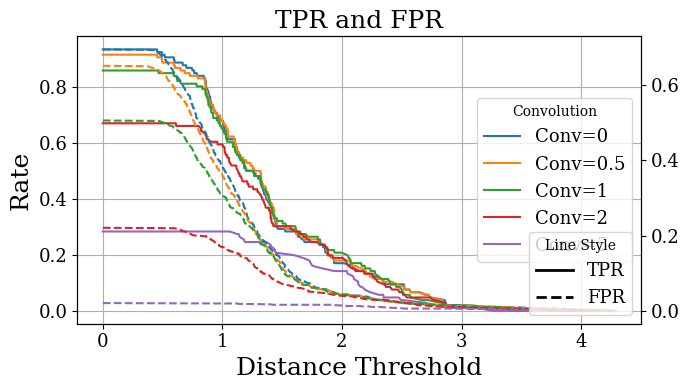

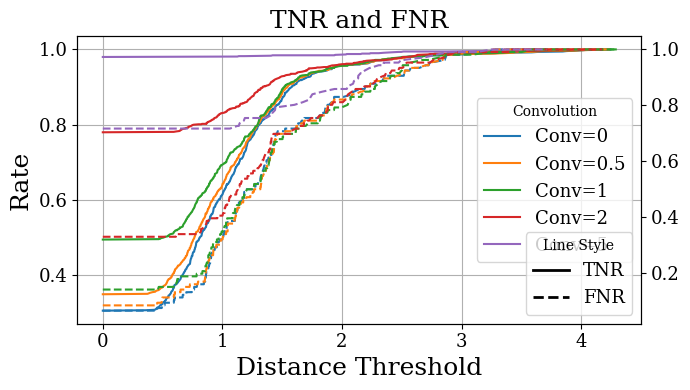

In [30]:
df = f150w_Table.copy()

distance = df['distance_pkpc']
has_psf = df['has_psf']
convolution = df['convolution']

# Step 1: Define ground truth from defined pairs
df['is_pair'] = np.isin(df['id'], pairs) & (df['has_psf'] == False)
df[df['is_pair']==True]

# Step 2: Loop over Rate Functions
for (f1, f2, solid_label, dashed_label) in [
    (get_tpr, get_fpr, 'TPR', 'FPR'),
    (get_tnr, get_fnr, 'TNR', 'FNR')
]:
    fig, ax = plt.subplots(figsize=(7, 4))
    axt = ax.twinx()

    # Loop over convolution values
    for conv in convolutions:
        mask_psf = (df['has_psf'] == True) & (df['convolution'] == conv)
        mask_nopsf = (df['has_psf'] == False) & (df['convolution'] == 0.0)

        dist_psf = df['distance_pkpc'][mask_psf]
        is_pair_nopsf = df['is_pair'][mask_nopsf]

        if len(dist_psf) == 0:
            continue

        # Calculate rates
        dist_thresholds, rate1_list = f1(dist_psf, is_pair_nopsf)
        _, rate2_list = f2(dist_psf, is_pair_nopsf)

        ax.plot(dist_thresholds, rate1_list, label=f'Conv={conv}')
        axt.plot(dist_thresholds, rate2_list, label=f'Conv={conv}', ls='--')

    # Main legend for convolution values
    ax.set_xlabel('Distance Threshold')
    ax.set_ylabel('Rate')
    ax.legend(title='Convolution', loc='center right')
    ax.set_title(f'{solid_label} and {dashed_label}')

    # Custom legend for line styles (solid vs dashed)
    from matplotlib.lines import Line2D
    style_legend = [
        Line2D([0], [0], color='black', lw=2, linestyle='-', label=solid_label),
        Line2D([0], [0], color='black', lw=2, linestyle='--', label=dashed_label)
    ]
    axt.legend(handles=style_legend, title='Line Style', loc='lower right')

    ax.grid(True)
    fig.tight_layout()
    plt.savefig(f'{img_path}/{solid_label}_vs_{dashed_label}.png')
    plt.show()
    



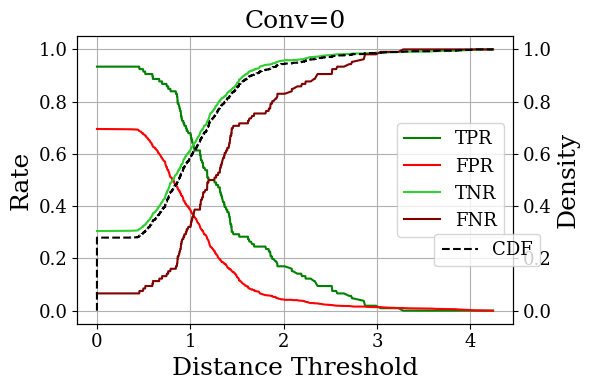

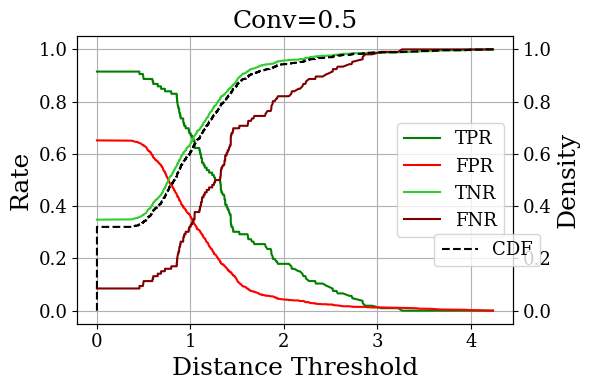

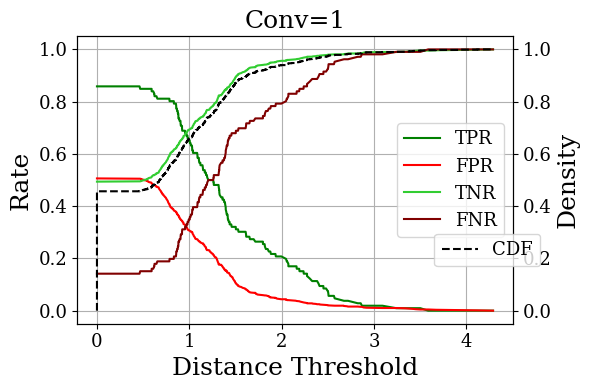

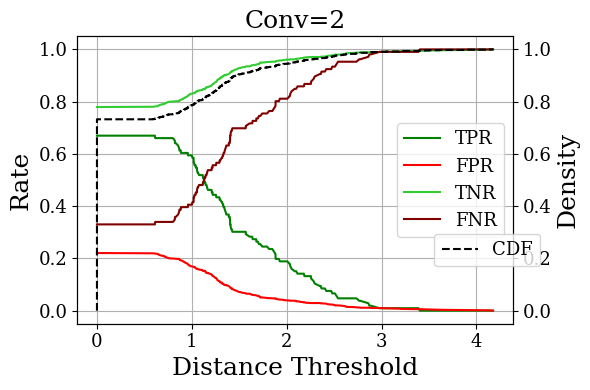

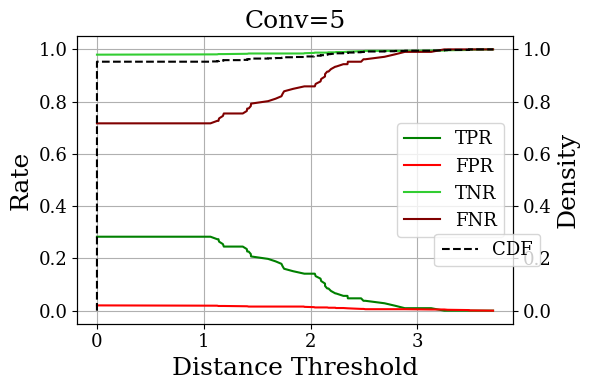

In [31]:
df = f150w_Table.copy()

distance = df['distance_pkpc']
has_psf = df['has_psf']
convolution = df['convolution']

# Step 1: Define ground truth from defined pairs
df['is_pair'] = np.isin(df['id'], pairs) & (df['has_psf'] == False)
df[df['is_pair']==True]


# Step 2: Loop over convolution values
for conv in convolutions:
    # new figure for each convolution
    fig, ax = plt.subplots(figsize=(6,4))
    axt = ax.twinx()

    # plot CDF for each convolution on the twin axis
    c = [0,0.5,1,2,5]
    df_dist = df[(df['convolution'] == conv) & (df['has_psf']==True)]['distance_pkpc']
    x,y = cumulative(df_dist)
    axt.step(x,y,color='black',linestyle='--',label='CDF')
    axt.set_ylabel(f"Density")
    axt.legend(loc=(0.82,0.2))

    # extract distance_pkpc and pairs from df
    mask_psf = (df['has_psf'] == True) & (df['convolution'] == conv)
    mask_nopsf = (df['has_psf'] == False) & (df['convolution'] == 0.0)

    dist_psf = (df['distance_pkpc'][mask_psf]) 
    is_pair_nopsf = df['is_pair'][mask_nopsf]
    
    if len(dist_psf) == 0:
        continue
    
    names = ['TPR','FPR','TNR','FNR']
    functions = (get_tpr,get_fpr,get_tnr,get_fnr)
    colors = ['green','red','limegreen','maroon']

    for i,func in enumerate(functions):
        thresholds,rate_list = func(dist_psf,is_pair_nopsf)
        ax.plot(thresholds, rate_list, label=f'{names[i]}',c=colors[i])
        # axt.plot(thresholds, rate2_list, label=f'Conv={conv}',ls='--')
        
# Plot ground truth threshold
    ax.set_xlabel('Distance Threshold')
    ax.set_ylabel('Rate')
    ax.set_title(f'Conv={conv}')
    ax.legend()
    ax.grid(True)
    fig.tight_layout()
    plt.savefig(f'{img_path}/all_rates_{conv}.png')
    plt.show()


In [32]:
# creating a dataframe that includes catalog data, roc data, and physical quantities
# RUN THIS BEFORE TPR HEATMAPS

# Load dataframes
og_catalog = Table.read(f'{code_path}/og_catalog.ecsv')
pandas_catalog = og_catalog.to_pandas()
catalog = pandas_catalog.copy()

roc_Table = Table.read('sep_Table.ecsv')
df = roc_Table.copy()
df['is_pair'] = np.isin(df['id'], pairs) & (df['has_psf'] == False)
convolutions = [0.0,0.5,1.0,2.0,5.0]

# Load FITS files and extract metadata
redshift = 7
bluetides_path = f'./jwst_all_*/hlsp_bluetides_jwst_nircam_z{redshift}*_f*w_v1_sim-*.fits'
filenames = glob.glob(bluetides_path)

# Store metadata
mass_list   = []
lum_list    = []
id_list     = list(catalog['id'])
stellarMass = list(catalog['stellarMass'])
lumFUV      = list(catalog['lum_FUV'])
        
# Add Mass and Luminosity to dataframe
meta_df = pd.DataFrame({'id': id_list, 'stellarMass': stellarMass, 'lumFUV': lumFUV})
df_pd = df.to_pandas()
df_merged = df_pd.merge(meta_df, on='id')

df

id,haloMass,bhMass,stellarMass,lumFUV,convolution,distances,flux_ratio,area_1,area_2,has_psf,is_pair
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,bool
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,0.0,5.8341918239615005,0.5927456669607006,50.0,60.0,False,False
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,0.5,11.315334820295579,0.2710036965865495,48.0,115.0,False,False
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,1.0,4.458249248190907,0.47129277006608244,85.0,176.0,False,False
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,2.0,0.0,0.0,0.0,0.0,False,False
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,5.0,0.0,0.0,0.0,0.0,False,False
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,0.0,0.0,0.0,0.0,0.0,True,False
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,0.5,0.0,0.0,0.0,0.0,True,False
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,1.0,0.0,0.0,0.0,0.0,True,False
1,1292328500000.0,374432960.0,62058380000.0,2.785938274534815e+29,2.0,0.0,0.0,0.0,0.0,True,False


[ 9.45899607  9.45899607  9.45899607 ... 11.11157724 11.11157724
 11.11157724]
[ 9.45899607  9.6426162   9.82623633 10.00985646 10.19347659 10.37709672
 10.56071685 10.74433698 10.92795711 11.11157724]
999
48
164
232
201
183
98
51
20
1
Skipping mass bin 8 due to small sample


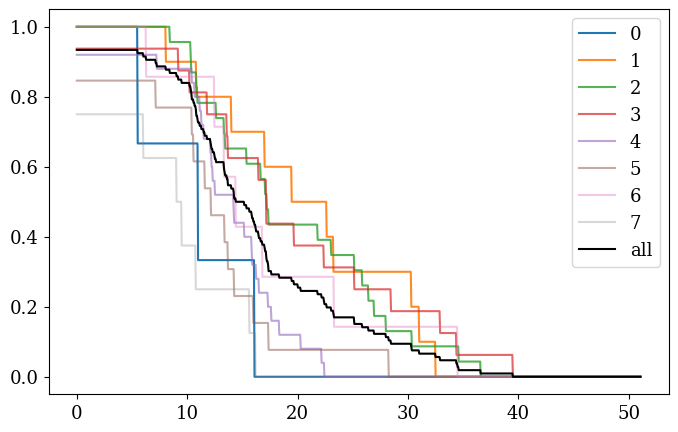

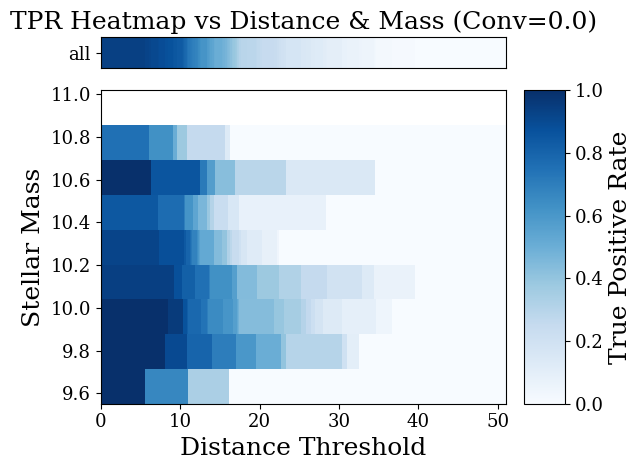

999
48
164
232
201
183
98
51
20
1
Skipping mass bin 8 due to small sample


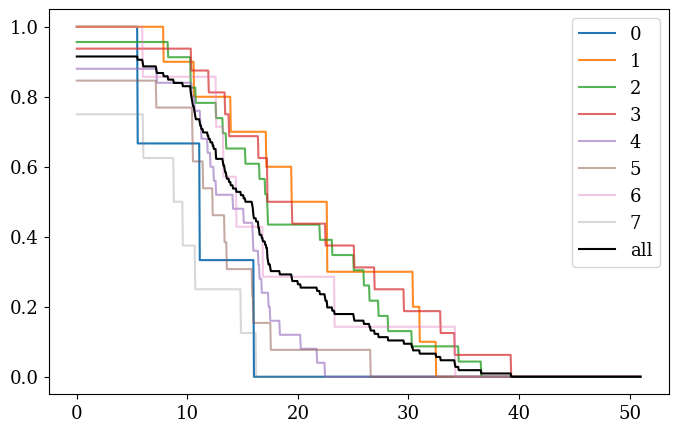

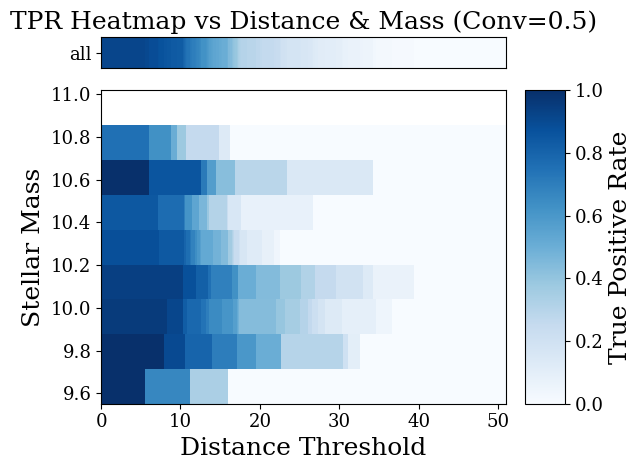

999
48
164
232
201
183
98
51
20
1
Skipping mass bin 8 due to small sample


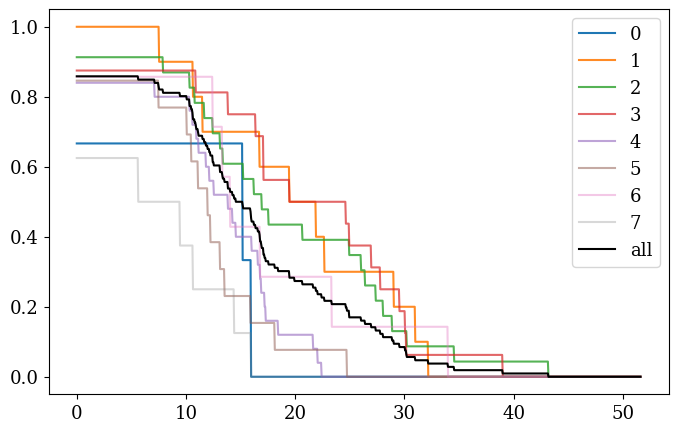

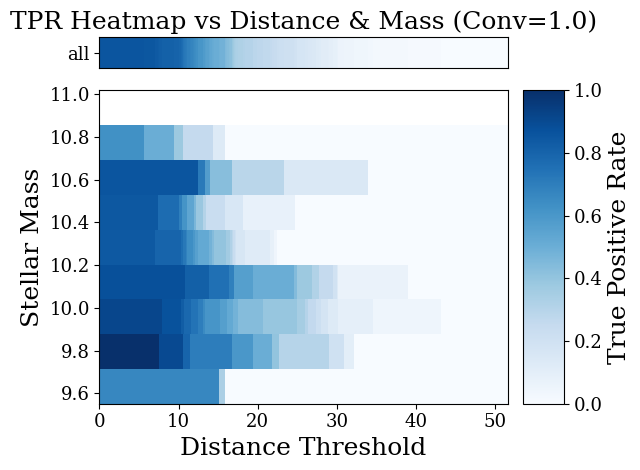

999
48
164
232
201
183
98
51
20
1
Skipping mass bin 8 due to small sample


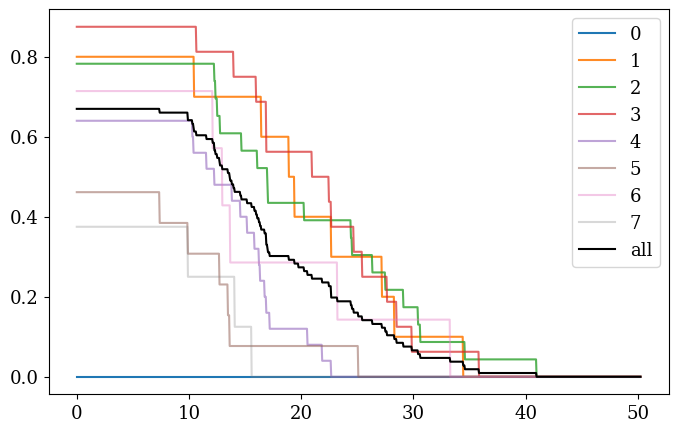

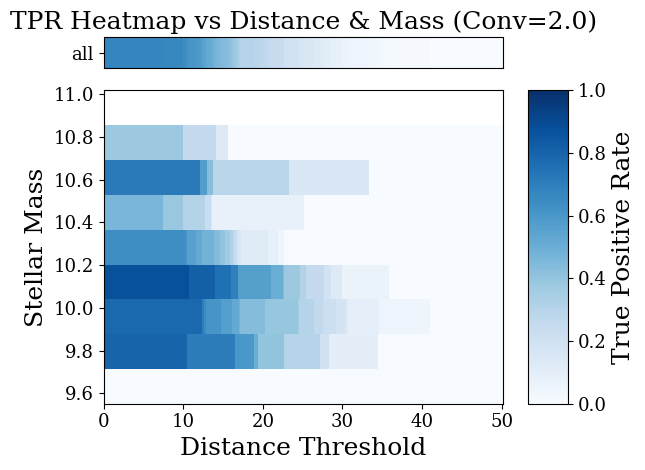

999
48
164
232
201
183
98
51
20
1
Skipping mass bin 8 due to small sample


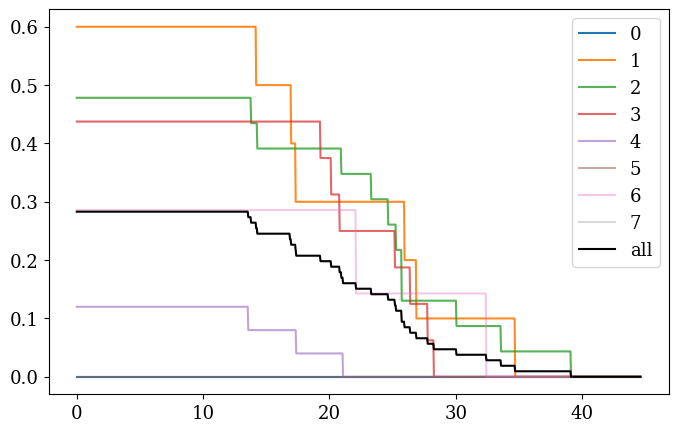

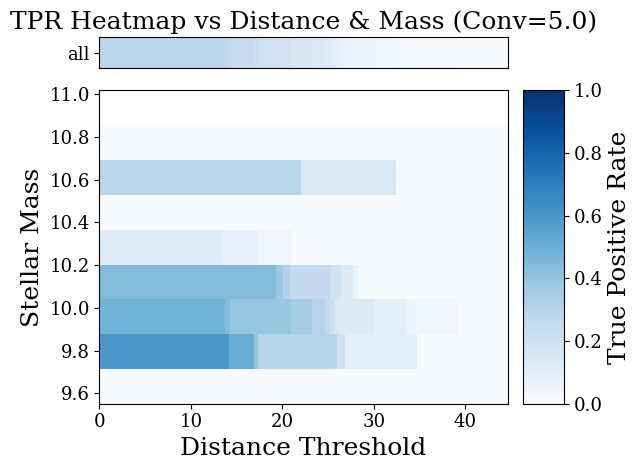

In [33]:
# Copy merged dataframe and define is_pair (only in no-PSF images)
df = roc_Table.copy()
df = df.to_pandas()
df['is_pair'] = np.isin(df['id'], pairs) & (df['has_psf'] == False)

# Define number of mass bins
nbins = 10

# Get mass bin edges 
mass_values = np.log10(df['stellarMass'].dropna())
# mass_values = df['lumFUV'].dropna()
sorted_mass = np.sort(mass_values)
print(sorted_mass)
# cum_prob = np.linspace(0, 1, len(sorted_mass))
# quantiles = np.linspace(0, 1, nbins + 1)
# mass_bins = np.interp(quantiles, cum_prob, sorted_mass)
mass_bins = np.linspace(sorted_mass[0], sorted_mass[-1],10)
print(mass_bins)
mass_bin_centers = 0.5 * (mass_bins[:-1] + mass_bins[1:])



# Loop over convolutions
for conv in convolutions:    
    # if conv == convolutions[1]:
    #     break
    # Mask for PSF sample at current convolution
    mask_psf   = (df['has_psf'] == True)  & (df['convolution'] == conv) # psf galaxies      
    mask_nopsf = (df['has_psf'] == False) & (df['convolution'] == 0.0)  # ground truth
    
    # Distance thresholds for this convolution
    dist_psf = df['distances'][mask_psf]
    is_pair_nopsf = df['is_pair'][mask_nopsf]
    thresholds, _ = cumulative(dist_psf)
    thresholds = np.linspace(thresholds[0], thresholds[-1],1000)
    # print(thresholds)
    
    # matrix to store TPR values per mass bin
    tpr_matrix = []

    # Create mask for PSF galaxies in this mass bin
    bin_mask = mask_psf 
    print(bin_mask.sum())


    # Get ground-truth labels from no-PSF images (conv==0)
    ids_bin = df.loc[bin_mask, 'id']
    dist_bin = df.loc[bin_mask, 'distances']

    # Get ground-truth "is_pair" values from the no-PSF (conv==0) sample
    df_truth = df[mask_nopsf]
    truth_dict = dict(zip(df_truth['id'], df_truth['is_pair']))

    # Match ground truth to PSF sample using IDs
    is_pair = ids_bin.map(truth_dict).fillna(False).astype(bool).values

    # run get_tpr
    thresholds_all, tpr_list_all = get_tpr(dist_bin, is_pair, fixed_thresholds=thresholds)

    plt.figure(figsize=(8, 5))
    
    for i in range(len(mass_bins) - 1):

        m_min = mass_bins[i]
        m_max = mass_bins[i + 1]

        # Create mask for PSF galaxies in this mass bin
        bin_mask = mask_psf & (np.log10(df['stellarMass']) >= m_min) & (np.log10(df['stellarMass']) < m_max)
        print(bin_mask.sum())

        if bin_mask.sum() < 5:
            print(f"Skipping mass bin {i} due to small sample")
            tpr_matrix.append(np.full(len(thresholds), np.nan))
            continue


        # Get ground-truth labels from no-PSF images (conv==0)
        ids_bin = df.loc[bin_mask, 'id']
        dist_bin = df.loc[bin_mask, 'distances']

        # Get ground-truth "is_pair" values from the no-PSF (conv==0) sample
        df_truth = df[mask_nopsf]
        truth_dict = dict(zip(df_truth['id'], df_truth['is_pair']))

        # Match ground truth to PSF sample using IDs
        is_pair = ids_bin.map(truth_dict).fillna(False).astype(bool).values

        # run get_tpr
        thresholds, tpr_list = get_tpr(dist_bin, is_pair, fixed_thresholds=thresholds)
        # thresholds2, tpr_list2 = get_tpr(dist_bin, is_pair)
        # print(thresholds)

        tpr_matrix.append(tpr_list)
        plt.plot(thresholds, tpr_list, alpha=1-0.1*i, label=f'{i}')
        # plt.plot(thresholds2, tpr_list2, alpha=1-0.1*i, label=f'{i}')
    plt.plot(thresholds_all, tpr_list_all, color='k', label='all')
    plt.legend()

    fig,((axt,ghost), (ax, cax)) = plt.subplots(ncols=2,nrows=2,width_ratios=[10,1],height_ratios=[1,10])
    # Plot heatmap

    im = ax.imshow(
        tpr_matrix,
        origin='lower',
        aspect='auto',
        extent=[
            thresholds[0], thresholds[-1],
            mass_bin_centers[0], mass_bin_centers[-1]
        ],
        cmap='Blues',
        interpolation='nearest',
        vmin=0,
        vmax=1
    )

    imt = axt.imshow(
        np.array(tpr_list_all)[None,:],
        origin='lower',
        aspect='auto',
        extent=[
            thresholds[0], thresholds[-1],
            0,1
        ],
        cmap='Blues',
        interpolation='nearest',
        vmin=0,
        vmax=1
    )

    axt.set_xticks([])
    axt.set_yticks([0.5])
    axt.set_yticklabels(['all'])

    ghost.set_axis_off()

    plt.colorbar(im, cax=cax,label='True Positive Rate')
    ax.set_xlabel('Distance Threshold')
    ax.set_ylabel('Stellar Mass')
    axt.set_title(f'TPR Heatmap vs Distance & Mass (Conv={conv})')
    fig.tight_layout()
    plt.savefig(f'{img_path}/tpr_heatmap{conv}.png')
    plt.show()


In [34]:
np.array(tpr_matrix[0])

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [35]:
#c ode for plotting TPR vs Mass and Luminosity

# Step 1: Load data
og_catalog = Table.read('og_catalog.ecsv')
pandas_catalog = og_catalog.to_pandas()
catalog = pandas_catalog.copy()

roc_Table = Table.read('sep_Table.ecsv')
df = roc_Table.copy()
df['is_pair'] = np.isin(df['id'], pairs) & (df['has_psf'] == False)
convolutions = [0.0,0.5,1.0,2.0,5.0]


# Step 2: Load FITS files and extract metadata
redshift = 7
bluetides_path = f'./jwst_all_*/hlsp_bluetides_jwst_nircam_z{redshift}*_f*w_v1_sim-*.fits'
filenames = glob.glob(bluetides_path)

# Store metadata
mass_list = []
lum_list  = []
id_list     = list(catalog['id'])
stellarMass = list(catalog['stellarMass'])
lumFUV      = list(catalog['lum_FUV'])
        

# Step 3: Add physical quantities to dataframe
meta_df = pd.DataFrame({'id': id_list, 'stellarMass': stellarMass, 'lumFUV': lumFUV})
df_pd = df.to_pandas()
df_merged = df_pd.merge(meta_df, on='id')

# fig, axs = plt.subplots(1, 2, figsize=(12, 4))


# Step 4: Compute TPR vs mass and luminosity
for conv in convolutions:
    mask_psf    = (df_merged['has_psf'] == True)  & (df_merged['convolution'] == conv)
    mask_nopsf  = (df_merged['has_psf'] == False) & (df_merged['convolution'] == 0.0)

    dist_psf = df['distances'][mask_psf]                        # measured distances
    mass_psf = np.array(df_merged['stellarMass'][mask_psf])     # stellar masses
    lum_psf  = np.array(df_merged['lumFUV'][mask_psf])          # FUV luminosities
    is_pair_nopsf = np.array(df_merged['is_pair'][mask_nopsf])  # true pairs
    
    dist_thresholds, dist_tpr = get_tpr(dist_psf, is_pair_nopsf)

    # axs[0].plot(mass_thresholds, mass_tpr, label=f'Conv={conv}')
    # axs[1].plot(lum_thresholds,  lum_tpr,  label=f'Conv={conv}')

    # Create the heatmap

    fig, ax = plt.subplots(figsize=(5, 4))
    c = ax.imshow(
        heatmap,
        origin='lower',
        aspect='auto',
        extent=[
            mass_thresholds[0], mass_thresholds[-1],
            dist_thresholds[0], dist_thresholds[-1]
        ],
        cmap='viridis'
    )
    ax.set_xlabel('Mass Threshold')
    ax.set_ylabel('Distance Threshold')
    ax.set_title(f'TPR Heatmap Conv={conv}')

    fig.colorbar(c, ax=ax, label='Combined TPR')
    plt.tight_layout()
    plt.show()

# Formatting
# axs[0].set_xlabel('Stellar Mass')
# axs[0].set_ylabel('True Positive Rate')
# axs[0].legend()
# axs[0].grid()
# axs[0].set_ylim(0,1.01)

# axs[1].set_xlabel('Luminosity FUV')
# axs[1].set_ylabel('True Positive Rate')
# axs[1].legend()
# axs[1].grid()
# axs[1].set_ylim(0,1.01)

plt.show()


KeyError: 'stellarMass'